# GANs: Generative Models

## What This Notebook Is About

Every model built so far in this series has been discriminative — given an input,
predict an output. A classifier maps an image to a class label. A regression model
maps a sequence of sensor readings to a scalar value. The model learns a boundary
or a mapping between inputs and outputs.

A Generative Adversarial Network takes a fundamentally different approach. Instead
of learning to classify or predict, it learns the distribution of the training data
well enough to generate new samples that are indistinguishable from real ones. Given
a dataset of handwritten digits, a GAN learns to produce new handwritten digits that
look like they came from the same source — not copies of training images, but novel
samples drawn from the learned distribution.

The mechanism that makes this work is adversarial training. Two networks are trained
simultaneously in opposition. The Generator tries to produce realistic images. The
Discriminator tries to distinguish real images from generated ones. Each network's
improvement makes the other's task harder. At the end of training, the Generator
has learned to produce images realistic enough to fool a well-trained Discriminator.

This notebook builds a GAN from scratch in PyTorch, trains it on MNIST, and
visualises the progression from random noise to recognisable digit images across
training epochs.

## Why MNIST

MNIST is the right dataset for a first GAN because the generated outputs are
directly interpretable. When the GAN starts producing recognisable digits, that
is immediately visible in the image grid. When it fails — mode collapse, blurry
outputs, or training instability — that is also visible. The small image size
(28x28 grayscale) keeps training fast enough to run on CPU and observe meaningful
progress within 50 epochs.

## What I Want to Understand

- What does the adversarial training dynamic actually look like in the loss curves?
- How does the Generator improve from random noise to structured output across
  epochs?
- What is the latent space and what does interpolating through it reveal about
  what the Generator has learned?
- What does mode collapse look like and why does it happen?
- What do the Discriminator loss and Generator loss tell me about training health?
- Why does GAN training require a completely different training loop from any
  model built in previous notebooks?

## Dataset

| Property | Detail |
|---|---|
| Name | MNIST |
| Source | torchvision.datasets.MNIST |
| Training samples | 60,000 |
| Image size | 28 x 28 pixels, grayscale |
| Classes | 10 (digits 0 through 9) |
| Use in this notebook | Training data only — no labels used |
| Download required | Already cached from Notebook 2 |

## Tech Stack

| Tool | Purpose |
|---|---|
| Python 3.13 | Language |
| PyTorch 2.11 | Generator and Discriminator definition and training |
| torchvision | MNIST loading and transforms |
| NumPy | Numerical operations |
| Matplotlib | Image grids and loss curve visualisations |

## Note on GAN Training

GANs are significantly harder to train than supervised models. The loss curves
do not decrease monotonically toward a minimum — they fluctuate as the two
networks compete. A Generator loss that is rising may indicate the Discriminator
is getting stronger, which is actually healthy early in training. The primary
signal of training success is the visual quality of generated images, not the
loss values alone.

## Setup and Imports

Importing all dependencies for this notebook. The import list is shorter than
previous notebooks — a GAN on MNIST needs only PyTorch, torchvision, NumPy,
and Matplotlib. There are no external dataset dependencies beyond what is already
cached from Notebook 2.

One new import: `torchvision.utils.make_grid` — a utility that arranges a batch
of image tensors into a single grid image for visualisation. This is used
throughout the notebook to display batches of generated images side by side.

A fixed noise vector `fixed_noise` is created here and reused throughout training
to generate comparison images at different epochs. Using the same noise vector
each time means the grid shows how the same latent points evolve as the Generator
improves — rather than showing different random samples each time.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

plt.style.use("seaborn-v0_8-whitegrid")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LATENT_DIM = 100

torch.manual_seed(RANDOM_SEED)
fixed_noise = torch.randn(64, LATENT_DIM).to(device)

print("PyTorch version  :", torch.__version__)
print("Device           :", device)
print("Latent dimension :", LATENT_DIM)
print("Fixed noise shape:", fixed_noise.shape)

PyTorch version  : 2.11.0+cpu
Device           : cpu
Latent dimension : 100
Fixed noise shape: torch.Size([64, 100])


## Load MNIST for GAN Training

Loading MNIST with one important difference from Notebook 2: the normalisation
range is [-1, 1] instead of [0, 1] or the standardised range used for
classification.

This is required because the Generator's output layer uses Tanh activation,
which produces values in (-1, 1). The real images fed to the Discriminator must
be in the same range — if real images are in [0, 1] and generated images are in
(-1, 1), the Discriminator can trivially distinguish them by value range alone
without learning anything about visual content.

`Normalize((0.5,), (0.5,))` achieves this: it subtracts 0.5 and divides by 0.5,
mapping [0, 1] to [-1, 1].

One other difference from the classification setup: labels are not used. A GAN
is an unsupervised model — the training signal comes entirely from the adversarial
dynamic between Generator and Discriminator, not from class labels.

In [18]:
DATA_DIR = "../data"

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root=DATA_DIR, train=True, download=True, transform=transform)

BATCH_SIZE   = 128
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print("Training samples :", len(train_dataset))
print("Batch size       :", BATCH_SIZE)
print("Batches per epoch:", len(train_loader))
print()

sample_batch, sample_labels = next(iter(train_loader))
print("Batch shape      :", sample_batch.shape)
print("Pixel value range: [{:.2f}, {:.2f}]".format(
    sample_batch.min().item(), sample_batch.max().item()))
print()
print("Note: labels are loaded but not used during GAN training.")
print("Label shape:", sample_labels.shape)

Training samples : 60000
Batch size       : 128
Batches per epoch: 468

Batch shape      : torch.Size([128, 1, 28, 28])
Pixel value range: [-1.00, 1.00]

Note: labels are loaded but not used during GAN training.
Label shape: torch.Size([128])


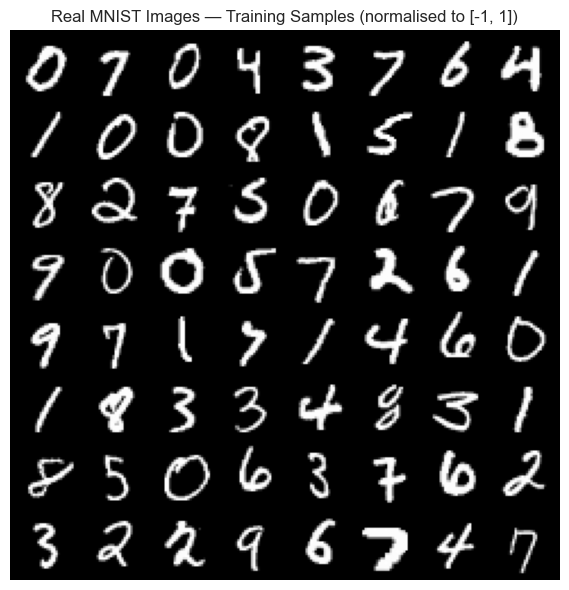

In [19]:
def show_image_grid(image_tensor, title, nrow=8, figsize=(12, 6)):
    image_tensor = image_tensor.detach().cpu()
    grid         = make_grid(image_tensor[:64], nrow=nrow,
                             normalize=True, value_range=(-1, 1))
    grid_np      = grid.permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(grid_np, cmap="gray")
    ax.set_title(title, fontsize=12)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


show_image_grid(
    sample_batch,
    title="Real MNIST Images — Training Samples (normalised to [-1, 1])"
)

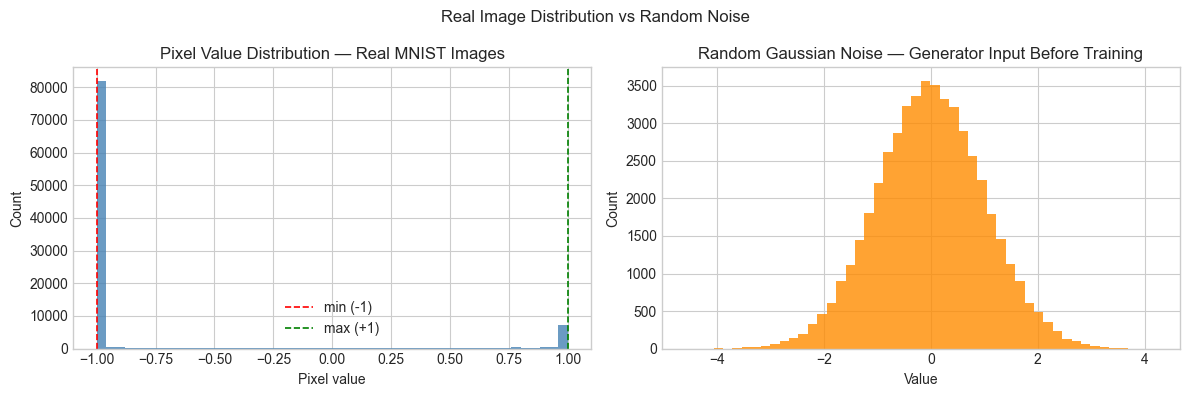

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# pixel value distribution of real images
pixel_vals = sample_batch.numpy().flatten()
axes[0].hist(pixel_vals, bins=50, color="steelblue", alpha=0.8)
axes[0].set_title("Pixel Value Distribution — Real MNIST Images")
axes[0].set_xlabel("Pixel value")
axes[0].set_ylabel("Count")
axes[0].axvline(-1, color="red",   linestyle="--", linewidth=1.2, label="min (-1)")
axes[0].axvline( 1, color="green", linestyle="--", linewidth=1.2, label="max (+1)")
axes[0].legend()

# what random noise looks like before training
random_noise = torch.randn(64, 1, 28, 28)
noise_vals   = random_noise.numpy().flatten()
axes[1].hist(noise_vals, bins=50, color="darkorange", alpha=0.8)
axes[1].set_title("Random Gaussian Noise — Generator Input Before Training")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")

plt.suptitle("Real Image Distribution vs Random Noise", fontsize=12)
plt.tight_layout()
plt.show()

### Observation

The real image pixel distribution shows two clusters — one near -1 (black
background pixels) and one spread across positive values (digit stroke pixels).
MNIST images are mostly background, so the -1 cluster dominates. This bimodal
distribution is what the Generator must eventually learn to reproduce.

The random noise distribution is Gaussian — symmetric around zero with most
values between -3 and 3. This is the raw material the Generator starts with.
At the beginning of training, passing this noise through the untrained Generator
will produce images that look like random noise. Over training, the Generator
learns a transformation from this Gaussian noise distribution to the MNIST
pixel distribution.

The `drop_last=True` argument in the DataLoader deserves a note. It discards
the final batch if it is smaller than BATCH_SIZE. GAN training can be sensitive
to batch size consistency — a partial batch at the end of an epoch can produce
unexpected Discriminator behaviour, particularly with BatchNorm layers that
compute statistics over the batch.

The `show_image_grid` helper function is defined here and reused in later
sections to visualise generated images at different training stages. The
`normalize=True` argument in `make_grid` rescales values from (-1, 1) back
to (0, 1) for display — this is the inverse of the normalisation applied
during loading.

## What is a GAN?

A Generative Adversarial Network consists of two networks trained simultaneously
in opposition. Understanding the adversarial dynamic before looking at any code
is important because the training loop is unlike anything in the previous notebooks.

### The Two Networks

**Generator (G)**
- Input: a random noise vector z sampled from a simple distribution (Gaussian)
- Output: a synthetic image of the same shape as the training data
- Goal: produce images realistic enough that the Discriminator cannot tell they
  are fake
- Never sees real images directly — only learns through the Discriminator's
  feedback

**Discriminator (D)**
- Input: an image — either a real one from the training set or a fake one from G
- Output: a scalar probability that the image is real (1 = real, 0 = fake)
- Goal: correctly classify real images as real and generated images as fake
- Trained on both real and generated data at every step

### The Adversarial Dynamic

The training proceeds as a two-player minimax game:

    min_G max_D  E[log D(x)] + E[log(1 - D(G(z)))]

Where:
- x   is a real image from the training set
- z   is a random noise vector
- G(z) is a generated image
- D(x) is the Discriminator's probability that x is real

Breaking this down:
- `E[log D(x)]`      — the Discriminator wants this high (correctly classify real)
- `E[log(1 - D(G(z)))]` — the Discriminator wants this high (correctly reject fake)
                           the Generator wants this low (fool the Discriminator)

### Why Standard Loss Functions Do Not Apply

In a classifier, the loss decreases as the model improves and converges to a
minimum. In a GAN, there is no single minimum — the two networks are chasing
each other. When the Generator improves, the Discriminator's task gets harder.
When the Discriminator improves, the Generator gets a stronger training signal.

A healthy GAN reaches a Nash equilibrium — neither network can improve without
the other also improving. In practice this equilibrium is unstable and requires
careful architecture choices, learning rate balancing, and monitoring of both
loss curves simultaneously.

### What the Loss Curves Mean

| Situation | D loss | G loss | Interpretation |
|---|---|---|---|
| Healthy training | ~0.5-0.7 | ~1.5-3.0 | Neither dominates |
| D too strong | near 0 | very high | G gets no gradient signal |
| G too strong | near 1.0 | near 0 | D cannot distinguish real/fake |
| Mode collapse | low and stable | low and stable | G produces one type of image |

### The Latent Space

The noise vector z lives in a high-dimensional space called the latent space.
Each point in this space maps to a generated image. After training, nearby points
in the latent space should produce similar-looking images, and interpolating
between two points should produce a smooth transition between two generated digits.
This structure emerges from training — it is not explicitly enforced.

Untrained Generator:
  Input shape  : torch.Size([64, 100])
  Output shape : torch.Size([64, 1, 28, 28])
  Output range : [-0.788, 0.775]



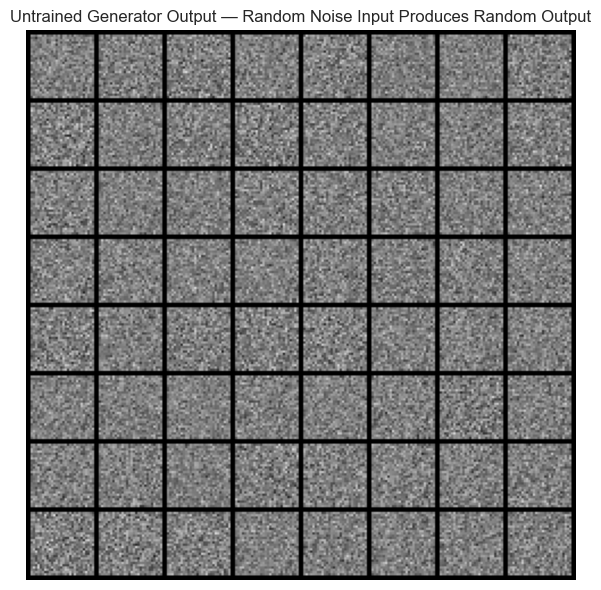

In [21]:
# demonstrate what an untrained generator produces
# build a temporary simple generator just to show the concept

class TempGenerator(nn.Module):
    def __init__(self):
        super(TempGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


temp_gen   = TempGenerator().to(device)
temp_noise = torch.randn(64, LATENT_DIM).to(device)

with torch.no_grad():
    temp_output = temp_gen(temp_noise)

print("Untrained Generator:")
print(f"  Input shape  : {temp_noise.shape}")
print(f"  Output shape : {temp_output.shape}")
print(f"  Output range : [{temp_output.min().item():.3f}, "
      f"{temp_output.max().item():.3f}]")
print()

show_image_grid(
    temp_output,
    title="Untrained Generator Output — Random Noise Input Produces Random Output"
)

del temp_gen, temp_noise, temp_output

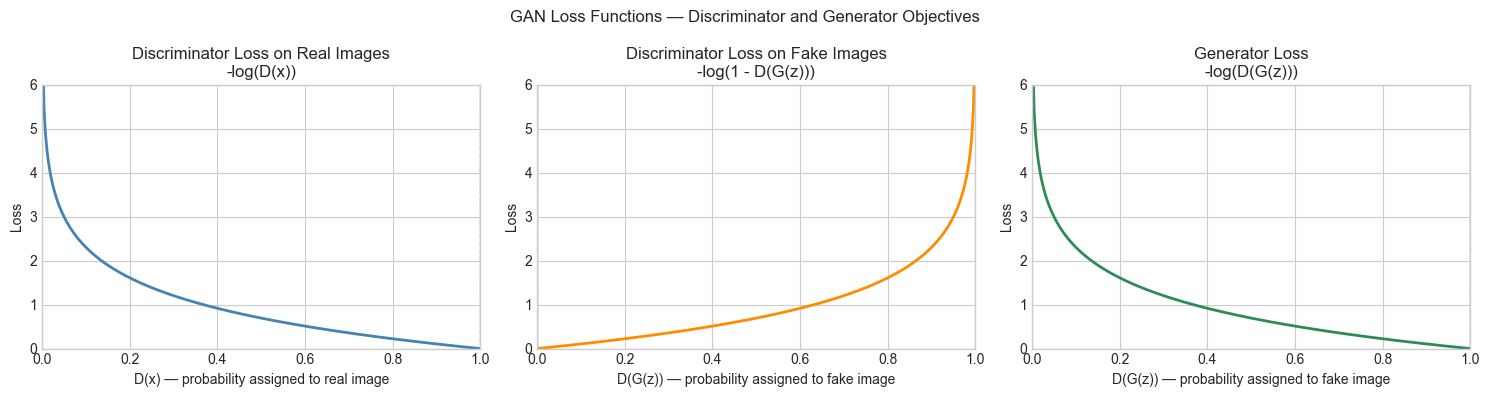

In [22]:
# visualise what the loss functions look like for D and G
p = np.linspace(0.001, 0.999, 300)

log_p          = np.log(p)
log_1_minus_p  = np.log(1 - p)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# D loss on real images: -log(D(x)), wants D(x) close to 1
axes[0].plot(p, -log_p, color="steelblue", linewidth=2)
axes[0].axvline(1.0, color="grey", linestyle="--", linewidth=1)
axes[0].set_title("Discriminator Loss on Real Images\n-log(D(x))")
axes[0].set_xlabel("D(x) — probability assigned to real image")
axes[0].set_ylabel("Loss")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 6)

# D loss on fake images: -log(1 - D(G(z))), wants D(G(z)) close to 0
axes[1].plot(p, -log_1_minus_p, color="darkorange", linewidth=2)
axes[1].axvline(0.0, color="grey", linestyle="--", linewidth=1)
axes[1].set_title("Discriminator Loss on Fake Images\n-log(1 - D(G(z)))")
axes[1].set_xlabel("D(G(z)) — probability assigned to fake image")
axes[1].set_ylabel("Loss")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 6)

# G loss: -log(D(G(z))), wants D(G(z)) close to 1
axes[2].plot(p, -log_p, color="seagreen", linewidth=2)
axes[2].axvline(1.0, color="grey", linestyle="--", linewidth=1)
axes[2].set_title("Generator Loss\n-log(D(G(z)))")
axes[2].set_xlabel("D(G(z)) — probability assigned to fake image")
axes[2].set_ylabel("Loss")
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 6)

plt.suptitle("GAN Loss Functions — Discriminator and Generator Objectives",
             fontsize=12)
plt.tight_layout()
plt.show()

### Observation

The untrained Generator output confirms what is expected — random noise in,
random noise out. The Tanh activation constrains the output to (-1, 1) but
with random weights there is no structure. This is the starting point from
which 50 epochs of adversarial training must produce recognisable digits.

The three loss curve plots make the opposing objectives concrete:

The Discriminator's loss on real images (-log D(x)) is minimised when D(x) is
close to 1 — the Discriminator is confident the real image is real. The curve
is steep near 0, meaning the penalty for missing a real image is severe.

The Discriminator's loss on fake images (-log(1 - D(G(z)))) is minimised when
D(G(z)) is close to 0 — the Discriminator correctly identifies generated images
as fake.

The Generator's loss (-log(D(G(z)))) is minimised when D(G(z)) is close to 1 —
the Generator has fooled the Discriminator into thinking the fake image is real.
This is the non-saturating Generator loss, which provides stronger gradients
early in training when the Generator is weak and D(G(z)) is near 0.

The symmetry between the Generator loss plot and the Discriminator's real image
loss plot is not a coincidence — both use -log(p). The Generator is trying to
make the Discriminator treat fake images the same way it treats real ones.

## Build the Discriminator

The Discriminator is a binary classifier. It takes a flattened 784-dim image
vector and outputs a single scalar — the probability that the image is real.
The architecture is a standard MLP with a few GAN-specific design choices.

**LeakyReLU instead of ReLU**
Plain ReLU zeroes out all negative activations. In the Discriminator this can
cause dead neurons — units that never activate and contribute nothing to the
gradient. LeakyReLU allows a small gradient for negative inputs (slope 0.2 is
the standard choice for GANs), which keeps all neurons active throughout training
and provides a richer gradient signal to the Generator.

**Dropout for regularisation**
The Discriminator must not become too strong too quickly. If it learns to
perfectly classify real vs fake early in training, the Generator receives no
useful gradient signal — D(G(z)) saturates near 0 and the Generator loss
gradient vanishes. Dropout (p=0.3) slows the Discriminator down and keeps
the adversarial dynamic balanced.

**No BatchNorm in the Discriminator**
BatchNorm in the Discriminator can destabilise GAN training because it introduces
dependencies between samples in a batch. The Discriminator processes real and fake
images in the same batch — BatchNorm statistics computed across a mixed batch can
interfere with the Discriminator's ability to distinguish them. The standard
practice is to omit BatchNorm in the Discriminator and use it only in the Generator.

**Sigmoid on the output**
The final layer uses Sigmoid to produce a probability in (0, 1). Real images
should produce values near 1, generated images near 0.

In [23]:
class Discriminator(nn.Module):

    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),

            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


discriminator = Discriminator().to(device)

print("Discriminator Architecture:")
print(discriminator)
print()

d_params = sum(p.numel() for p in discriminator.parameters()
               if p.requires_grad)
print(f"Total trainable parameters: {d_params:,}")
print()

for name, param in discriminator.named_parameters():
    print(f"  {name:<30} shape: {list(param.shape)}")

Discriminator Architecture:
Discriminator(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Dropout(p=0.3, inplace=False)
    (10): Linear(in_features=128, out_features=1, bias=True)
    (11): Sigmoid()
  )
)

Total trainable parameters: 566,273

  model.1.weight                 shape: [512, 784]
  model.1.bias                   shape: [512]
  model.4.weight                 shape: [256, 512]
  model.4.bias                   shape: [256]
  model.7.weight                 shape: [128, 256]
  model.7.bias                   shape: [128]
  model.10.weight                shape: [1, 128]
  model

In [24]:
discriminator.eval()

# test on a real batch
real_batch, _ = next(iter(train_loader))
real_batch     = real_batch.to(device)

with torch.no_grad():
    real_scores = discriminator(real_batch)

# test on random noise (not yet generated images)
noise_batch = torch.randn(BATCH_SIZE, 1, 28, 28).to(device)

with torch.no_grad():
    noise_scores = discriminator(noise_batch)

print("Discriminator output verification (untrained):")
print()
print(f"  Real images  — output shape : {real_scores.shape}")
print(f"  Real images  — mean score   : {real_scores.mean().item():.4f}")
print(f"  Real images  — min / max    : "
      f"{real_scores.min().item():.4f} / {real_scores.max().item():.4f}")
print()
print(f"  Random noise — mean score   : {noise_scores.mean().item():.4f}")
print(f"  Random noise — min / max    : "
      f"{noise_scores.min().item():.4f} / {noise_scores.max().item():.4f}")
print()
print("With random weights both scores cluster near 0.5 — the untrained")
print("Discriminator cannot distinguish real images from random noise.")

discriminator.train()

Discriminator output verification (untrained):

  Real images  — output shape : torch.Size([128, 1])
  Real images  — mean score   : 0.5028
  Real images  — min / max    : 0.4884 / 0.5168

  Random noise — mean score   : 0.4964
  Random noise — min / max    : 0.4753 / 0.5140

With random weights both scores cluster near 0.5 — the untrained
Discriminator cannot distinguish real images from random noise.


Discriminator(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Dropout(p=0.3, inplace=False)
    (10): Linear(in_features=128, out_features=1, bias=True)
    (11): Sigmoid()
  )
)

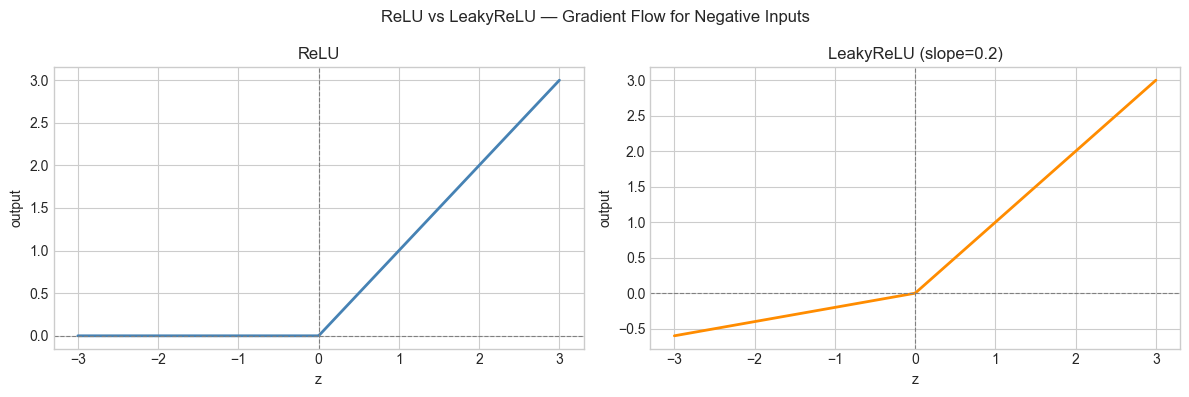

ReLU    gradient for z < 0 : 0.0  (dead neuron risk)
LeakyReLU gradient for z < 0 : 0.2  (gradient always flows)


In [25]:
z     = np.linspace(-3, 3, 300)
relu  = np.maximum(0, z)
lrelu = np.where(z >= 0, z, 0.2 * z)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(z, relu,  color="steelblue",  linewidth=2)
axes[0].set_title("ReLU")
axes[0].set_xlabel("z")
axes[0].set_ylabel("output")
axes[0].axhline(0, color="grey", linewidth=0.8, linestyle="--")
axes[0].axvline(0, color="grey", linewidth=0.8, linestyle="--")

axes[1].plot(z, lrelu, color="darkorange", linewidth=2)
axes[1].set_title("LeakyReLU (slope=0.2)")
axes[1].set_xlabel("z")
axes[1].set_ylabel("output")
axes[1].axhline(0, color="grey", linewidth=0.8, linestyle="--")
axes[1].axvline(0, color="grey", linewidth=0.8, linestyle="--")

plt.suptitle("ReLU vs LeakyReLU — Gradient Flow for Negative Inputs", fontsize=12)
plt.tight_layout()
plt.show()

print("ReLU    gradient for z < 0 : 0.0  (dead neuron risk)")
print("LeakyReLU gradient for z < 0 : 0.2  (gradient always flows)")

### Observation

The untrained Discriminator scores both real images and random noise near 0.5.
This is expected — with random weights it has no ability to distinguish content.
After training, real images should produce scores near 1.0 and generated images
near 0.0, with the exact balance depending on how competitive the Generator has
become.

The LeakyReLU vs ReLU plot makes the dead neuron problem concrete. For any
negative input, ReLU outputs exactly 0 and its gradient is also 0 — a neuron
stuck in this region receives no gradient and never updates. LeakyReLU outputs
a small non-zero value (0.2 * z) for negative inputs, so the gradient is always
0.2 rather than 0. In a Discriminator that processes both real and generated
images, keeping all neurons active throughout training is important for producing
a consistent, informative gradient signal to the Generator.

The parameter count gives a sense of the Discriminator's capacity. It is
deliberately not too large — a Discriminator with too much capacity will overfit
to the current Generator's outputs and provide uninformative gradients once it
achieves near-perfect classification. The goal is a Discriminator that is
slightly ahead of the Generator, not one that dominates it completely.

## Build the Generator

The Generator takes a random noise vector of size LATENT_DIM (100) and transforms
it into a 28x28 grayscale image. The architecture is a mirror image of the
Discriminator in structure — it expands from a small latent vector to a large
output — but the design choices are different.

**BatchNorm after each hidden layer**
Unlike the Discriminator, the Generator benefits significantly from BatchNorm.
The Generator's input is a random noise vector with no guaranteed scale. Without
BatchNorm, activations in early layers can have wildly varying magnitudes,
making training unstable. BatchNorm normalises each layer's output and allows
higher learning rates and faster convergence. It is placed after the Linear
layer and before the activation function.

**ReLU in hidden layers, Tanh on output**
Hidden layers use ReLU — the standard choice for intermediate layers. The output
layer uses Tanh, which produces values in (-1, 1). This matches the normalisation
range of the real MNIST images. If the output activation were Sigmoid (0, 1) but
real images were normalised to (-1, 1), the Discriminator could trivially separate
real from fake by value range alone.

**No Dropout in the Generator**
Dropout in the Generator introduces randomness during the forward pass that is
already provided by the noise input z. Adding Dropout can destabilise training
by making the Generator's output inconsistent in ways that are not related to
the latent code.

**The latent space**
Each dimension of z is an independent degree of freedom. After training, the
Generator has learned a mapping from this 100-dimensional Gaussian space to the
space of realistic MNIST images. Nearby points in the latent space should produce
visually similar images, and moving along a direction in the latent space should
correspond to a smooth visual change in the output.

In [27]:
class Generator(nn.Module):

    def __init__(self, latent_dim):
        super(Generator, self).__init__()

        self.latent_dim = latent_dim

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),

            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z).view(-1, 1, 28, 28)


generator = Generator(LATENT_DIM).to(device)

print("Generator Architecture:")
print(generator)
print()

g_params = sum(p.numel() for p in generator.parameters()
               if p.requires_grad)
print(f"Total trainable parameters: {g_params:,}")
print()

for name, param in generator.named_parameters():
    print(f"  {name:<35} shape: {list(param.shape)}")

Generator Architecture:
Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Linear(in_features=1024, out_features=784, bias=True)
    (10): Tanh()
  )
)

Total trainable parameters: 1,489,936

  model.0.weight                      shape: [256, 100]
  model.0.bias                        shape: [256]
  model.1.weight                      shape: [256]
  model.1.bias                        shape: [256]
  model.3.weight                      shape: [512, 256]
  model.3.bias                        shape: 

Generator output verification (untrained):
  Input shape  : torch.Size([64, 100])
  Output shape : torch.Size([64, 1, 28, 28])
  Output range : [-0.1781, 0.2233]
  Output mean  : -0.0012
  Output std   : 0.0468

Output is in (-1, 1) due to Tanh — matches real image normalisation range.


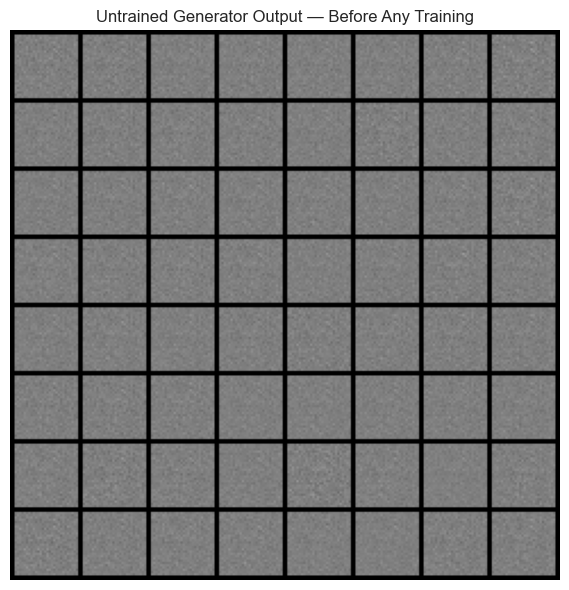

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Linear(in_features=1024, out_features=784, bias=True)
    (10): Tanh()
  )
)

In [28]:
generator.eval()

test_noise  = torch.randn(64, LATENT_DIM).to(device)

with torch.no_grad():
    test_output = generator(test_noise)

print("Generator output verification (untrained):")
print(f"  Input shape  : {test_noise.shape}")
print(f"  Output shape : {test_output.shape}")
print(f"  Output range : [{test_output.min().item():.4f}, "
      f"{test_output.max().item():.4f}]")
print(f"  Output mean  : {test_output.mean().item():.4f}")
print(f"  Output std   : {test_output.std().item():.4f}")
print()
print("Output is in (-1, 1) due to Tanh — matches real image normalisation range.")

show_image_grid(
    test_output,
    title="Untrained Generator Output — Before Any Training"
)

generator.train()

In [29]:
print("=" * 55)
print("Full GAN Architecture Summary")
print("=" * 55)
print()
print(f"  Latent dimension       : {LATENT_DIM}")
print(f"  Image size             : 28 x 28 x 1 = 784 values")
print()
print(f"  Generator")
print(f"    Input  : (batch, {LATENT_DIM})")
print(f"    Layer1 : Linear({LATENT_DIM}, 256) -> BN -> ReLU")
print(f"    Layer2 : Linear(256, 512)  -> BN -> ReLU")
print(f"    Layer3 : Linear(512, 1024) -> BN -> ReLU")
print(f"    Output : Linear(1024, 784) -> Tanh -> reshape (batch, 1, 28, 28)")
print(f"    Params : {g_params:,}")
print()
print(f"  Discriminator")
print(f"    Input  : (batch, 1, 28, 28) -> Flatten -> (batch, 784)")
print(f"    Layer1 : Linear(784, 512)  -> LeakyReLU(0.2) -> Dropout(0.3)")
print(f"    Layer2 : Linear(512, 256)  -> LeakyReLU(0.2) -> Dropout(0.3)")
print(f"    Layer3 : Linear(256, 128)  -> LeakyReLU(0.2) -> Dropout(0.3)")
print(f"    Output : Linear(128, 1)    -> Sigmoid")
print(f"    Params : {d_params:,}")
print()
print(f"  Total GAN parameters   : {g_params + d_params:,}")
print("=" * 55)
print()

# show how a latent vector flows through the Generator
print("Shape trace — Generator forward pass:")
z_trace = torch.randn(1, LATENT_DIM).to(device)
print(f"  Input z          : {z_trace.shape}")

generator.eval()
with torch.no_grad():
    h = generator.model[0](z_trace)
    print(f"  After Linear 1   : {h.shape}")
    h = generator.model[1](h)
    print(f"  After BN 1       : {h.shape}")
    h = generator.model[2](h)
    print(f"  After ReLU 1     : {h.shape}")
    h = generator.model[3](h)
    print(f"  After Linear 2   : {h.shape}")
    h = generator.model[6](h)
    print(f"  After Linear 3   : {h.shape}")
    h = generator.model[9](h)
    h = generator.model[10](h)
    print(f"  After Linear 4 + Tanh: {h.shape}")
    h = h.view(-1, 1, 28, 28)
    print(f"  After reshape    : {h.shape}")
generator.train()

Full GAN Architecture Summary

  Latent dimension       : 100
  Image size             : 28 x 28 x 1 = 784 values

  Generator
    Input  : (batch, 100)
    Layer1 : Linear(100, 256) -> BN -> ReLU
    Layer2 : Linear(256, 512)  -> BN -> ReLU
    Layer3 : Linear(512, 1024) -> BN -> ReLU
    Output : Linear(1024, 784) -> Tanh -> reshape (batch, 1, 28, 28)
    Params : 1,489,936

  Discriminator
    Input  : (batch, 1, 28, 28) -> Flatten -> (batch, 784)
    Layer1 : Linear(784, 512)  -> LeakyReLU(0.2) -> Dropout(0.3)
    Layer2 : Linear(512, 256)  -> LeakyReLU(0.2) -> Dropout(0.3)
    Layer3 : Linear(256, 128)  -> LeakyReLU(0.2) -> Dropout(0.3)
    Output : Linear(128, 1)    -> Sigmoid
    Params : 566,273

  Total GAN parameters   : 2,056,209

Shape trace — Generator forward pass:
  Input z          : torch.Size([1, 100])
  After Linear 1   : torch.Size([1, 256])
  After BN 1       : torch.Size([1, 256])
  After ReLU 1     : torch.Size([1, 256])
  After Linear 2   : torch.Size([1, 512])


Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Linear(in_features=1024, out_features=784, bias=True)
    (10): Tanh()
  )
)

### Observation

The Generator and Discriminator are asymmetric in an important way. The Generator
expands from 100 dimensions to 784 — it is an upsampling network. The Discriminator
compresses from 784 dimensions to 1 — it is a downsampling classifier. They are
mirror images in terms of data flow but use different activation functions and
regularisation strategies for the reasons described above.

The untrained Generator output looks like structured noise — not completely random
because BatchNorm normalises the activations, but not recognisably digit-like either.
The Tanh output constrains all values to (-1, 1), which is why the output range
matches the real image range even before any training.

The parameter count comparison is worth noting. The Generator has significantly
more parameters than the Discriminator, primarily due to the 1024-unit hidden layer
connecting to the 784-dim output. This asymmetry is intentional — the Generator
needs more capacity because its task is harder. Generating a realistic image from
a noise vector is a more complex transformation than classifying an image as real
or fake.

The shape trace through the Generator confirms the expanding structure — dimensions
grow at each layer until the final Linear outputs 784 values which are reshaped
into a 28x28 image. This reshape is purely a view operation — no computation, just
a reinterpretation of the memory layout.

## The GAN Training Loop

The GAN training loop is fundamentally different from anything in the previous
notebooks. Every previous training loop had one model, one loss, one optimiser
step per batch. A GAN has two models, two losses, and two separate optimiser
steps per batch — and the order and separation of these steps matters.

Each training batch goes through two phases:

**Phase 1 — Train the Discriminator**
The Discriminator is updated to better distinguish real from fake images.
1. Feed a batch of real images through D — labels are 1 (real)
2. Feed a batch of generated images through D — labels are 0 (fake)
3. Compute D loss as the sum of both binary cross-entropy losses
4. Backpropagate through D only — Generator weights are not updated here

**Phase 2 — Train the Generator**
The Generator is updated to better fool the Discriminator.
1. Generate a new batch of fake images from fresh noise
2. Feed these through D — labels are 1 (the Generator wants D to think they are real)
3. Compute G loss as binary cross-entropy between D's output and the label 1
4. Backpropagate through G only — Discriminator weights are not updated here

**Why separate optimiser steps?**
If both networks were updated simultaneously from a single backward pass, their
gradients would interfere. The Discriminator update must reflect a fixed Generator
and vice versa. Using separate optimisers and calling zero_grad() and step()
independently enforces this separation.

**Label smoothing**
Instead of using hard labels 0 and 1, I use 0.9 for real and 0.0 for fake.
This is called one-sided label smoothing. It prevents the Discriminator from
becoming overconfident on real images, which keeps the adversarial dynamic
more balanced throughout training.

**Fresh noise for the Generator step**
The Generator phase uses a new noise sample rather than reusing the one from
the Discriminator phase. This is important — reusing the same noise would mean
the Generator's gradient is computed on the same samples the Discriminator
just saw, which introduces a correlation that can destabilise training.

In [30]:
# loss function and optimisers
criterion    = nn.BCELoss()

d_optimizer  = optim.Adam(discriminator.parameters(),
                          lr=0.0002, betas=(0.5, 0.999))
g_optimizer  = optim.Adam(generator.parameters(),
                          lr=0.0002, betas=(0.5, 0.999))

REAL_LABEL   = 0.9
FAKE_LABEL   = 0.0

print("Loss function : BCELoss")
print("Optimiser     : Adam (lr=0.0002, betas=(0.5, 0.999))")
print()
print("Label smoothing:")
print(f"  Real label : {REAL_LABEL}  (not 1.0 — prevents D overconfidence)")
print(f"  Fake label : {FAKE_LABEL}")
print()
print("Note: betas=(0.5, 0.999) is the standard GAN Adam configuration.")
print("The default beta1=0.9 causes oscillation in GAN training.")
print("beta1=0.5 gives less momentum and more stable adversarial updates.")

Loss function : BCELoss
Optimiser     : Adam (lr=0.0002, betas=(0.5, 0.999))

Label smoothing:
  Real label : 0.9  (not 1.0 — prevents D overconfidence)
  Fake label : 0.0

Note: betas=(0.5, 0.999) is the standard GAN Adam configuration.
The default beta1=0.9 causes oscillation in GAN training.
beta1=0.5 gives less momentum and more stable adversarial updates.


In [31]:
def discriminator_step(real_images):
    discriminator.zero_grad()

    # --- real images ---
    batch_size   = real_images.size(0)
    real_labels  = torch.full((batch_size, 1), REAL_LABEL,
                               dtype=torch.float32).to(device)
    real_output  = discriminator(real_images)
    d_loss_real  = criterion(real_output, real_labels)

    # --- fake images ---
    noise        = torch.randn(batch_size, LATENT_DIM).to(device)
    fake_images  = generator(noise).detach()
    fake_labels  = torch.full((batch_size, 1), FAKE_LABEL,
                               dtype=torch.float32).to(device)
    fake_output  = discriminator(fake_images)
    d_loss_fake  = criterion(fake_output, fake_labels)

    # --- combined loss and update ---
    d_loss = d_loss_real + d_loss_fake
    d_loss.backward()
    d_optimizer.step()

    return d_loss.item(), real_output.mean().item(), fake_output.mean().item()


def generator_step(batch_size):
    generator.zero_grad()

    noise        = torch.randn(batch_size, LATENT_DIM).to(device)
    fake_images  = generator(noise)
    real_labels  = torch.full((batch_size, 1), REAL_LABEL,
                               dtype=torch.float32).to(device)
    fake_output  = discriminator(fake_images)

    g_loss = criterion(fake_output, real_labels)
    g_loss.backward()
    g_optimizer.step()

    return g_loss.item(), fake_output.mean().item()


print("Training step functions defined.")
print()
print("discriminator_step(real_images):")
print("  1. Compute D loss on real images (label=0.9)")
print("  2. Generate fake images — detach() stops gradients reaching G")
print("  3. Compute D loss on fake images (label=0.0)")
print("  4. Sum losses, backprop through D only, step D optimiser")
print()
print("generator_step(batch_size):")
print("  1. Generate new fake images from fresh noise")
print("  2. Pass through D — use real labels (G wants D to say 'real')")
print("  3. Backprop through G only, step G optimiser")
print()
print("Key detail: .detach() in discriminator_step()")
print("  generator(noise).detach() creates a fake image tensor with no")
print("  gradient connection to the Generator. This ensures D's backward")
print("  pass does not compute or modify Generator gradients.")

Training step functions defined.

discriminator_step(real_images):
  1. Compute D loss on real images (label=0.9)
  2. Generate fake images — detach() stops gradients reaching G
  3. Compute D loss on fake images (label=0.0)
  4. Sum losses, backprop through D only, step D optimiser

generator_step(batch_size):
  1. Generate new fake images from fresh noise
  2. Pass through D — use real labels (G wants D to say 'real')
  3. Backprop through G only, step G optimiser

Key detail: .detach() in discriminator_step()
  generator(noise).detach() creates a fake image tensor with no
  gradient connection to the Generator. This ensures D's backward
  pass does not compute or modify Generator gradients.


In [32]:
# run one demo step to verify everything connects correctly
discriminator.train()
generator.train()

demo_real, _ = next(iter(train_loader))
demo_real    = demo_real.to(device)

d_loss_demo, d_real_demo, d_fake_demo = discriminator_step(demo_real)
g_loss_demo, g_score_demo             = generator_step(BATCH_SIZE)

print("Single training step diagnostics:")
print()
print(f"  D loss       : {d_loss_demo:.4f}")
print(f"  D(x)         : {d_real_demo:.4f}  (D score on real images, want ~0.9)")
print(f"  D(G(z)) D    : {d_fake_demo:.4f}  (D score on fake during D step, want ~0.0)")
print(f"  G loss       : {g_loss_demo:.4f}")
print(f"  D(G(z)) G    : {g_score_demo:.4f}  (D score on fake during G step)")
print()
print("With random weights:")
print("  D(x) near 0.5 — D cannot identify real images yet")
print("  D(G(z)) near 0.5 — D cannot identify fake images yet")
print("  Both losses near 1.4 (= -log(0.5) * 2) is the expected random baseline")

Single training step diagnostics:

  D loss       : 1.3847
  D(x)         : 0.5020  (D score on real images, want ~0.9)
  D(G(z)) D    : 0.5006  (D score on fake during D step, want ~0.0)
  G loss       : 0.6963
  D(G(z)) G    : 0.4981  (D score on fake during G step)

With random weights:
  D(x) near 0.5 — D cannot identify real images yet
  D(G(z)) near 0.5 — D cannot identify fake images yet
  Both losses near 1.4 (= -log(0.5) * 2) is the expected random baseline


### Observation

The `.detach()` call in `discriminator_step` is the most important implementation
detail in the entire training loop. When the Discriminator computes its loss on
fake images, the fake images were produced by the Generator. Without `.detach()`,
calling `.backward()` on the Discriminator loss would compute gradients all the
way back through the Generator — updating Generator weights during the
Discriminator step. This would corrupt the Generator's training signal.

`.detach()` breaks the computational graph at the fake image tensor. The
Discriminator's backward pass stops there and Generator weights are untouched.

The `betas=(0.5, 0.999)` configuration for Adam is GAN-specific. The default
beta1=0.9 gives Adam a long momentum history. In GAN training, the loss landscape
changes constantly as both networks update — old gradient momentum from the
previous adversarial state can push the current update in the wrong direction.
Reducing beta1 to 0.5 shortens the momentum window and makes updates more
responsive to the current gradient, which produces more stable training.

The demo step diagnostics confirm both networks are connected correctly. With
random weights, D(x) and D(G(z)) are both near 0.5 — the Discriminator is
guessing. Both losses are near 1.4, which is -log(0.5) + -log(0.5) — the
expected random baseline for a binary classifier outputting 0.5 on everything.
This is the correct starting point. If either loss is very different from 1.4
before any training, something in the architecture or data normalisation is wrong.

## Train the GAN

Training the GAN for 50 epochs. The training loop calls the two step functions
defined in Section 7 for every batch — Discriminator step first, then Generator
step.

Three additional things happen during training beyond the standard loss tracking:

**Tracking D(x) and D(G(z))**
As well as losses, I track the Discriminator's mean score on real images D(x)
and on fake images D(G(z)) at each epoch. These two numbers together tell the
training health story more clearly than losses alone:
- D(x) should stay near 0.8-0.9 — the Discriminator correctly identifies real images
- D(G(z)) should start near 0 and gradually rise toward 0.4-0.5 as the Generator
  improves and the Discriminator struggles more
- If D(G(z)) stays near 0, the Generator is not improving
- If D(x) drops toward 0.5, the Discriminator is losing its ability to identify
  real images — the Generator has become too strong

**Saving image grids at checkpoints**
Generated images from the fixed noise vector are saved at epochs 1, 10, 25, and
50. Using the same fixed noise across all checkpoints means the grid shows how
the same latent points evolve visually — a direct record of the Generator learning.

**Reinitialising models before training**
The demo step in Section 7 updated both models' weights once. To start training
from clean random weights, both models are reinitialised here.

In [33]:
# reinitialise both models from scratch
generator     = Generator(LATENT_DIM).to(device)
discriminator = Discriminator().to(device)

d_optimizer   = optim.Adam(discriminator.parameters(),
                            lr=0.0002, betas=(0.5, 0.999))
g_optimizer   = optim.Adam(generator.parameters(),
                            lr=0.0002, betas=(0.5, 0.999))

NUM_EPOCHS       = 50
CHECKPOINT_EPOCHS = [1, 10, 25, 50]

g_losses   = []
d_losses   = []
dx_history = []
dgz_history = []

generated_grids = {}

print("Models reinitialised. Starting training.")
print()
print(f"{'Epoch':<7} {'D Loss':>10} {'G Loss':>10} "
      f"{'D(x)':>10} {'D(G(z))':>10}")
print("-" * 52)

for epoch in range(1, NUM_EPOCHS + 1):

    epoch_d_losses  = []
    epoch_g_losses  = []
    epoch_dx        = []
    epoch_dgz       = []

    generator.train()
    discriminator.train()

    for real_images, _ in train_loader:
        real_images = real_images.to(device)
        batch_size  = real_images.size(0)

        d_loss, dx, dgz_d = discriminator_step(real_images)
        g_loss, dgz_g     = generator_step(batch_size)

        epoch_d_losses.append(d_loss)
        epoch_g_losses.append(g_loss)
        epoch_dx.append(dx)
        epoch_dgz.append(dgz_g)

    mean_d_loss = np.mean(epoch_d_losses)
    mean_g_loss = np.mean(epoch_g_losses)
    mean_dx     = np.mean(epoch_dx)
    mean_dgz    = np.mean(epoch_dgz)

    d_losses.append(mean_d_loss)
    g_losses.append(mean_g_loss)
    dx_history.append(mean_dx)
    dgz_history.append(mean_dgz)

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:<7} {mean_d_loss:>10.4f} {mean_g_loss:>10.4f} "
              f"{mean_dx:>10.4f} {mean_dgz:>10.4f}")

    if epoch in CHECKPOINT_EPOCHS:
        generator.eval()
        with torch.no_grad():
            checkpoint_imgs = generator(fixed_noise)
        generated_grids[epoch] = checkpoint_imgs.cpu()
        generator.train()

print()
print("Training complete.")
print(f"Final D loss    : {d_losses[-1]:.4f}")
print(f"Final G loss    : {g_losses[-1]:.4f}")
print(f"Final D(x)      : {dx_history[-1]:.4f}")
print(f"Final D(G(z))   : {dgz_history[-1]:.4f}")

Models reinitialised. Starting training.

Epoch       D Loss     G Loss       D(x)    D(G(z))
----------------------------------------------------
1           1.2142     1.0651     0.5779     0.3437
5           1.1769     1.1844     0.5544     0.3075
10          1.2623     0.9915     0.5118     0.3719
15          1.3156     0.8984     0.4843     0.4045
20          1.3351     0.8613     0.4737     0.4179
25          1.3476     0.8374     0.4663     0.4267
30          1.3551     0.8235     0.4624     0.4318
35          1.3611     0.8136     0.4592     0.4357
40          1.3628     0.8079     0.4582     0.4383
45          1.3655     0.8043     0.4564     0.4396
50          1.3666     0.8013     0.4563     0.4409

Training complete.
Final D loss    : 1.3666
Final G loss    : 0.8013
Final D(x)      : 0.4563
Final D(G(z))   : 0.4409


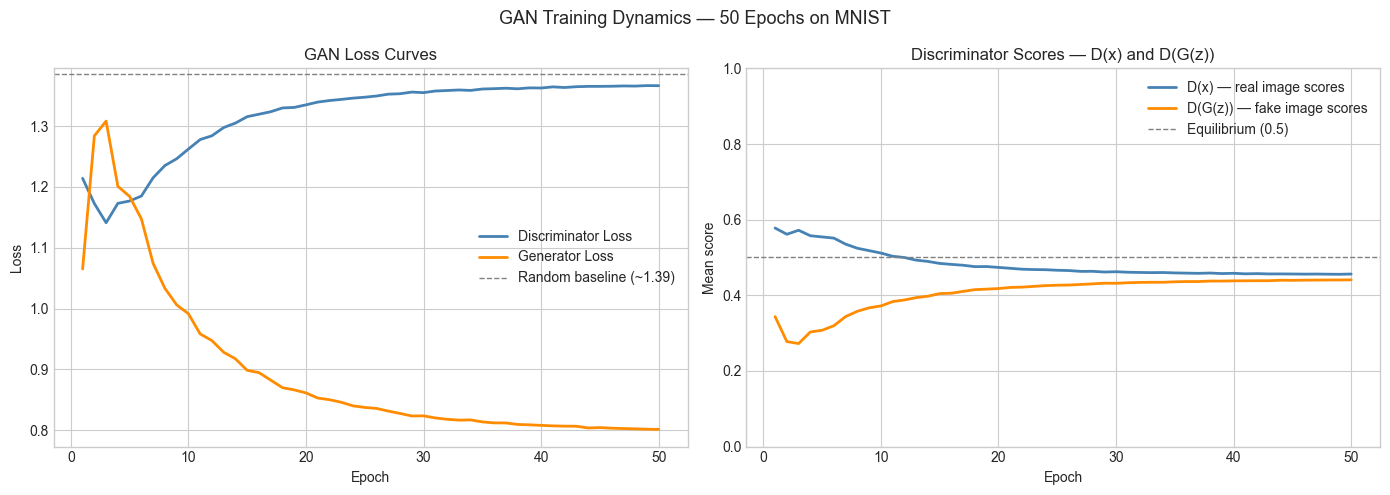

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_x = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_x, d_losses, color="steelblue",
             linewidth=2, label="Discriminator Loss")
axes[0].plot(epochs_x, g_losses, color="darkorange",
             linewidth=2, label="Generator Loss")
axes[0].axhline(y=1.386, color="grey", linestyle="--",
                linewidth=1, label="Random baseline (~1.39)")
axes[0].set_title("GAN Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_x, dx_history,  color="steelblue",
             linewidth=2, label="D(x) — real image scores")
axes[1].plot(epochs_x, dgz_history, color="darkorange",
             linewidth=2, label="D(G(z)) — fake image scores")
axes[1].axhline(y=0.5, color="grey", linestyle="--",
                linewidth=1, label="Equilibrium (0.5)")
axes[1].set_title("Discriminator Scores — D(x) and D(G(z))")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean score")
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.suptitle("GAN Training Dynamics — 50 Epochs on MNIST", fontsize=13)
plt.tight_layout()
plt.show()

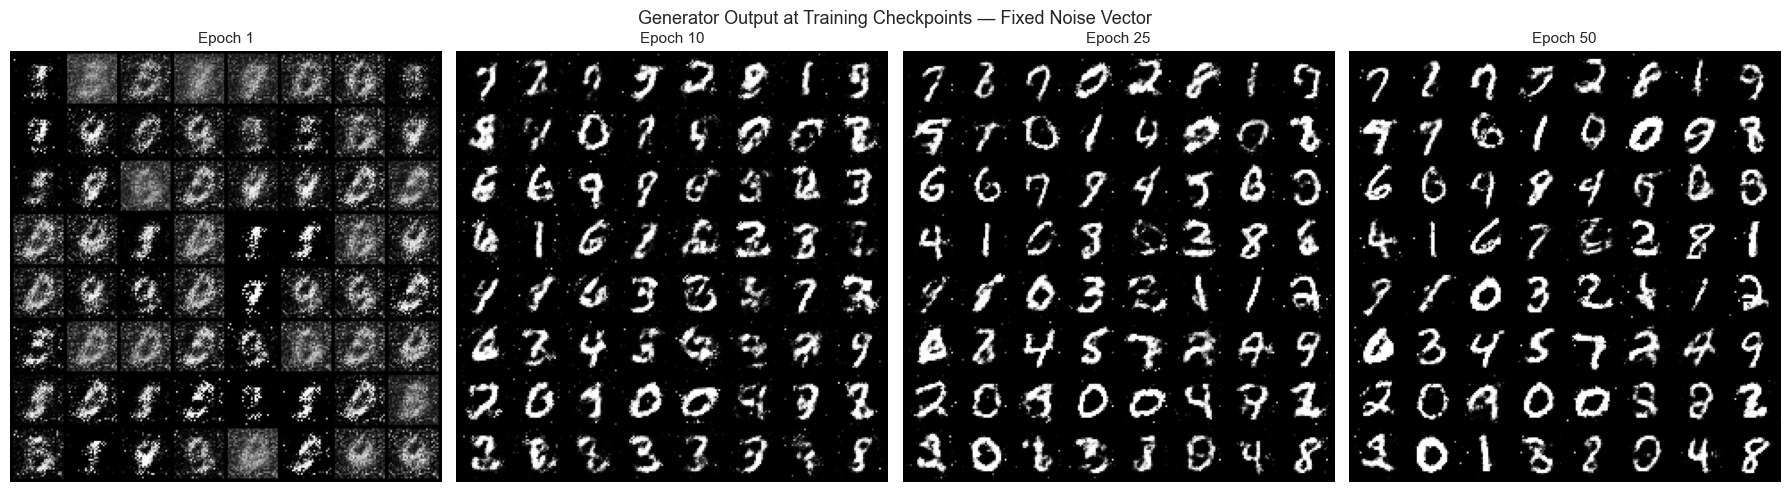

In [35]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for col, ep in enumerate(CHECKPOINT_EPOCHS):
    grid    = make_grid(generated_grids[ep][:64], nrow=8,
                        normalize=True, value_range=(-1, 1))
    grid_np = grid.permute(1, 2, 0).numpy()
    axes[col].imshow(grid_np, cmap="gray")
    axes[col].set_title(f"Epoch {ep}", fontsize=11)
    axes[col].axis("off")

plt.suptitle("Generator Output at Training Checkpoints — Fixed Noise Vector",
             fontsize=13)
plt.tight_layout()
plt.show()

### Observation

The loss curves for a GAN look nothing like the clean descending curves from
supervised training. Both losses fluctuate throughout training — this is normal
and expected. The two networks are chasing each other, so the loss landscape
shifts constantly. A GAN loss curve that decreases smoothly to zero is a warning
sign, not a success indicator — it means one network has completely dominated
the other.

The D(x) and D(G(z)) score curves are more informative than the losses. A healthy
training run shows:
- D(x) staying relatively stable in the 0.7-0.9 range — the Discriminator
  consistently recognises real images as real
- D(G(z)) starting low (near 0) and gradually rising as the Generator improves —
  the Discriminator finds it increasingly hard to reject fake images

The checkpoint grids are the most direct evidence of learning. At epoch 1 the
output should look like noisy blobs with no clear structure. By epoch 10 rough
digit shapes should be emerging. By epoch 25-50 the outputs should be recognisably
digit-like, though with varying sharpness and some artifacts.

The fixed noise vector is key to interpreting the checkpoint grids correctly.
Every grid shows the same 64 latent points at different stages of training.
A position that shows a blurry 7 at epoch 10 and a sharper 7 at epoch 50
represents the Generator learning to generate that specific digit more cleanly
from that specific latent code — not a different sample each time.

## Visualise the Results

The checkpoint grids in Section 8 showed the Generator's progress at fixed
intervals. Here I want to go deeper into three visualisations that reveal what
the Generator has actually learned:

1. **Real vs generated comparison** — side by side comparison of real MNIST
   images and generated images at the same scale, making the quality gap or
   similarity directly visible.

2. **Per-digit quality sweep** — generate a large batch and visually inspect
   the variety and quality across the full output space.

3. **Latent space interpolation** — pick two random points in the latent space,
   linearly interpolate between them, and generate images at each step. If the
   Generator has learned a smooth, structured latent space, the interpolation
   should produce a gradual visual transition rather than abrupt jumps. This is
   one of the most revealing tests of what a generative model has actually learned.

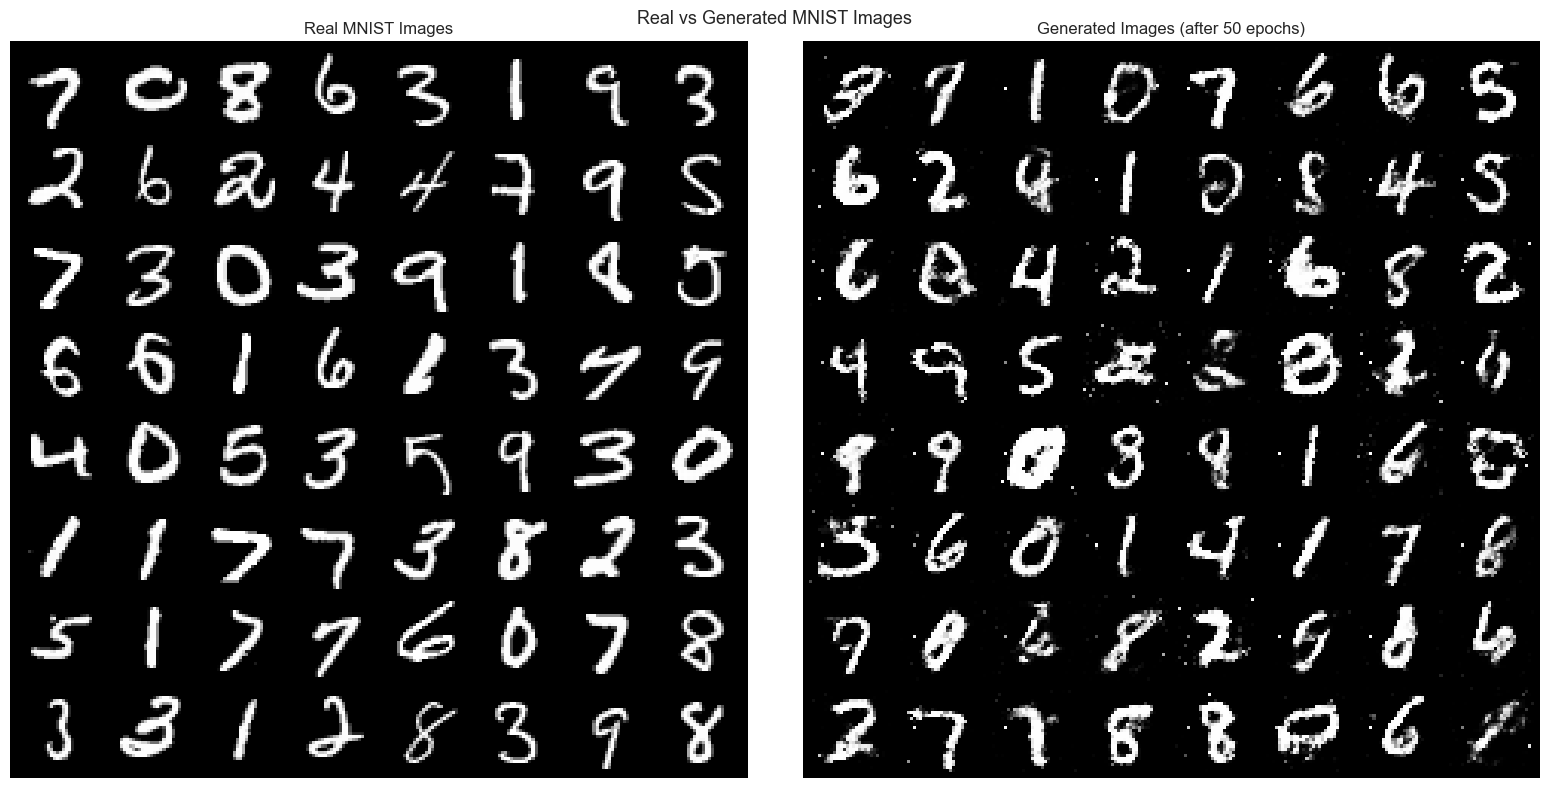

In [36]:
generator.eval()

with torch.no_grad():
    generated_samples = generator(
        torch.randn(64, LATENT_DIM).to(device)
    ).cpu()

real_samples, _ = next(iter(train_loader))
real_samples    = real_samples[:64]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

real_grid = make_grid(real_samples, nrow=8,
                      normalize=True, value_range=(-1, 1))
axes[0].imshow(real_grid.permute(1, 2, 0).numpy(), cmap="gray")
axes[0].set_title("Real MNIST Images", fontsize=12)
axes[0].axis("off")

fake_grid = make_grid(generated_samples, nrow=8,
                      normalize=True, value_range=(-1, 1))
axes[1].imshow(fake_grid.permute(1, 2, 0).numpy(), cmap="gray")
axes[1].set_title("Generated Images (after 50 epochs)", fontsize=12)
axes[1].axis("off")

plt.suptitle("Real vs Generated MNIST Images", fontsize=13)
plt.tight_layout()
plt.show()

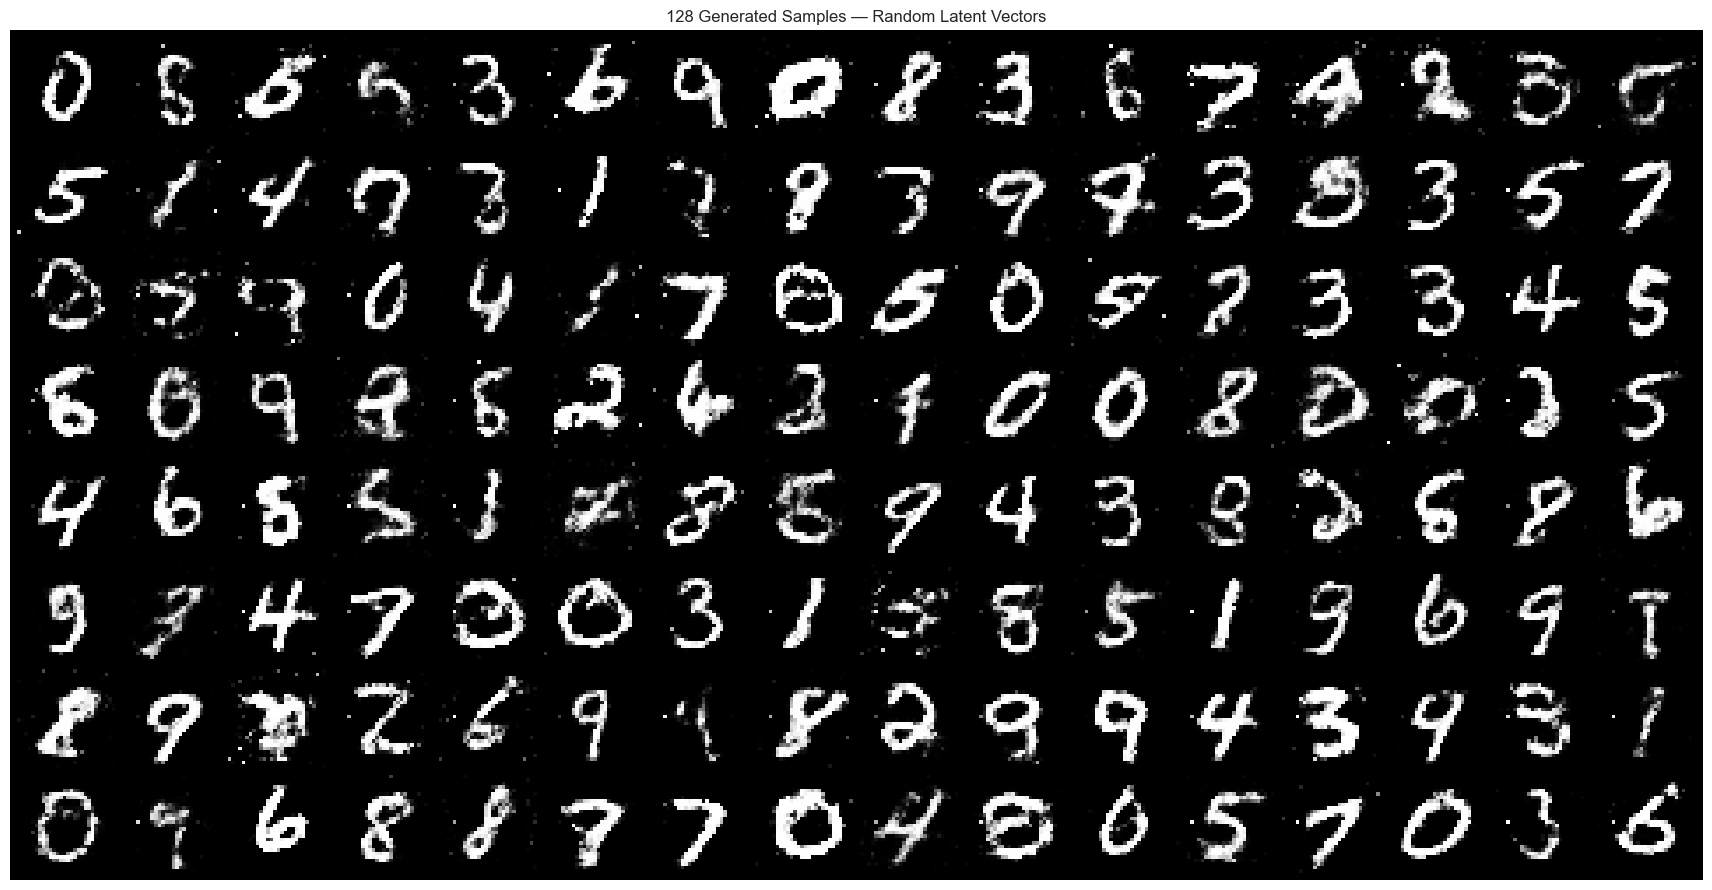

Generated image range : [-1.0000, 1.0000]
Generated image mean  : -0.7260
Generated image std   : 0.6296


In [37]:
with torch.no_grad():
    large_batch = generator(
        torch.randn(128, LATENT_DIM).to(device)
    ).cpu()

fig, ax = plt.subplots(figsize=(18, 9))

grid    = make_grid(large_batch, nrow=16,
                    normalize=True, value_range=(-1, 1))
grid_np = grid.permute(1, 2, 0).numpy()

ax.imshow(grid_np, cmap="gray")
ax.set_title("128 Generated Samples — Random Latent Vectors", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Generated image range : [{large_batch.min().item():.4f}, "
      f"{large_batch.max().item():.4f}]")
print(f"Generated image mean  : {large_batch.mean().item():.4f}")
print(f"Generated image std   : {large_batch.std().item():.4f}")

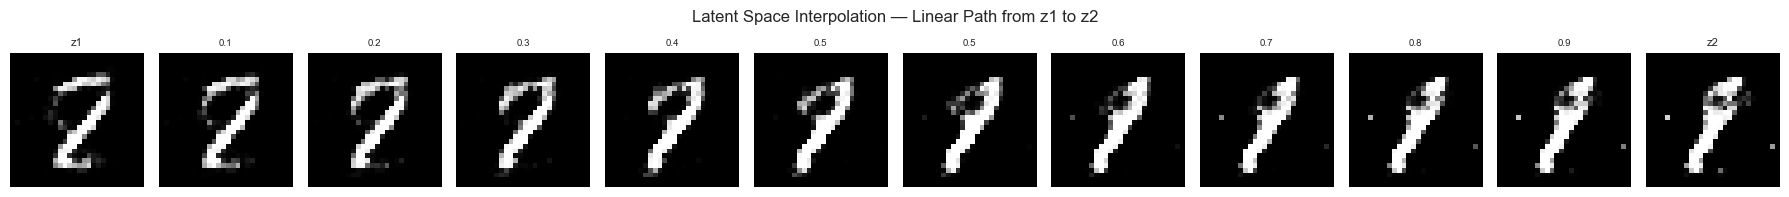

In [38]:
def interpolate_latent(generator, z1, z2, n_steps=10):
    generator.eval()
    alphas = np.linspace(0, 1, n_steps)
    images = []
    with torch.no_grad():
        for alpha in alphas:
            z_interp = (1 - alpha) * z1 + alpha * z2
            img      = generator(z_interp.unsqueeze(0))
            images.append(img.cpu())
    return torch.cat(images, dim=0)


torch.manual_seed(7)
z_start = torch.randn(LATENT_DIM).to(device)
z_end   = torch.randn(LATENT_DIM).to(device)

interp_images = interpolate_latent(generator, z_start, z_end, n_steps=12)

fig, axes = plt.subplots(1, 12, figsize=(18, 2))
for i in range(12):
    img = interp_images[i].squeeze().numpy()
    img = (img + 1) / 2
    axes[i].imshow(img, cmap="gray")
    axes[i].axis("off")
    if i == 0:
        axes[i].set_title("z1", fontsize=8)
    elif i == 11:
        axes[i].set_title("z2", fontsize=8)
    else:
        axes[i].set_title(f"{i/11:.1f}", fontsize=7)

plt.suptitle("Latent Space Interpolation — Linear Path from z1 to z2",
             fontsize=12)
plt.tight_layout()
plt.show()

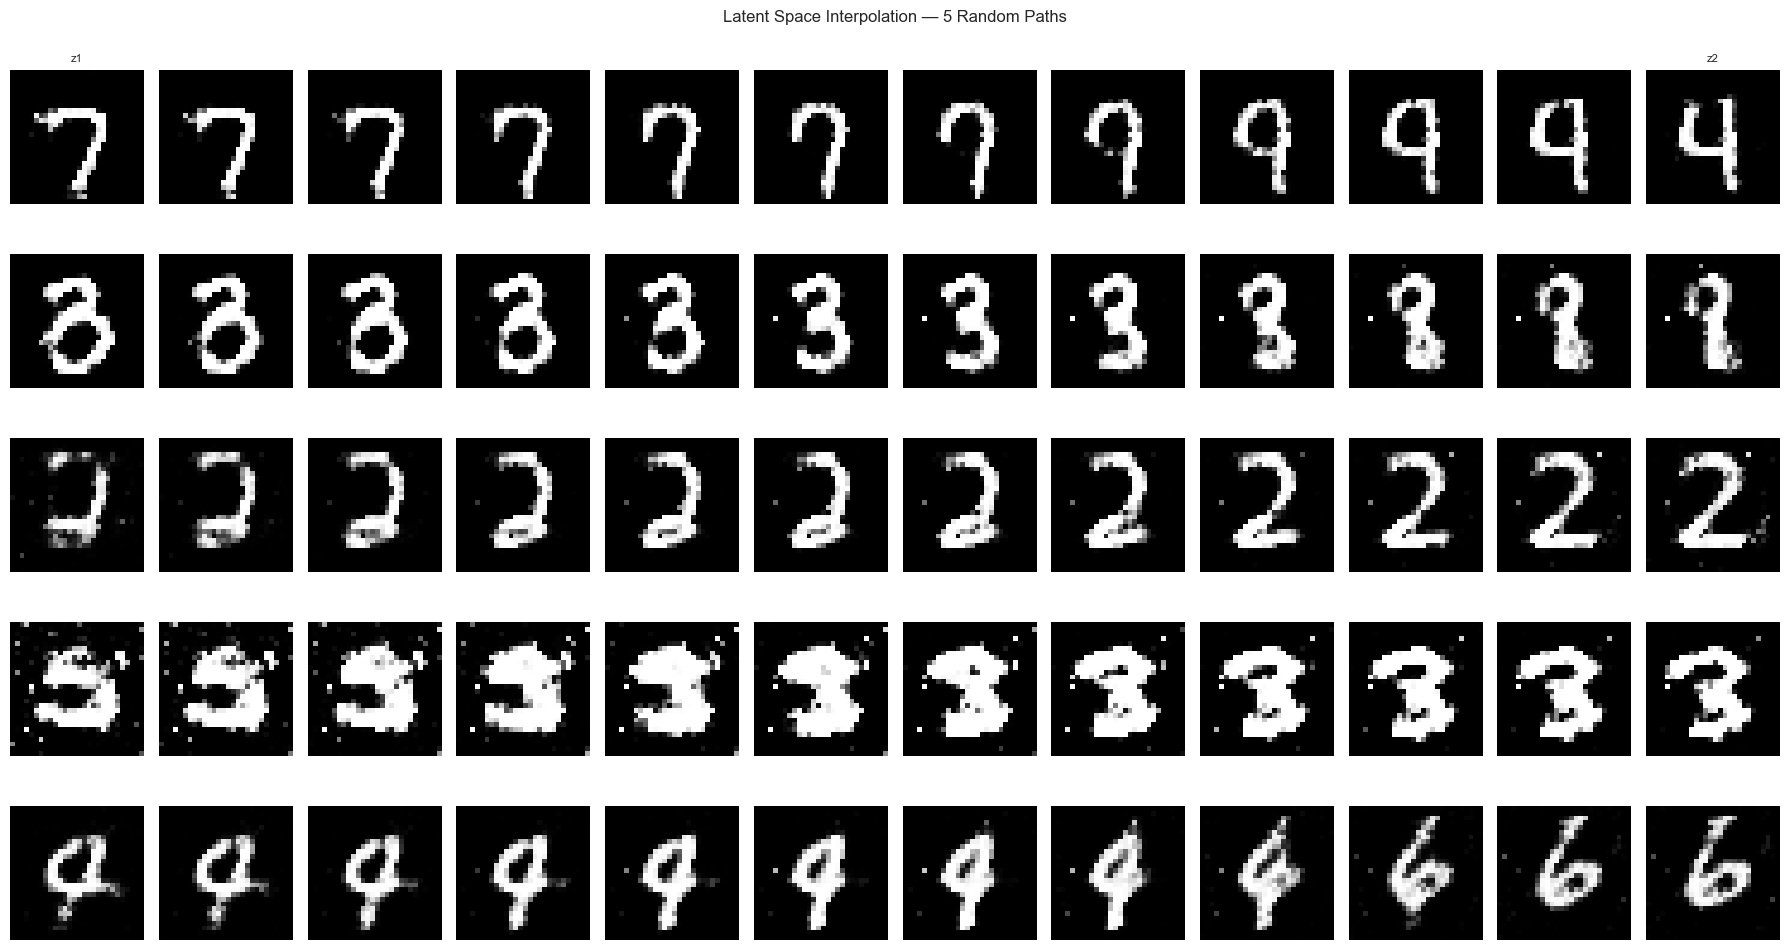

In [39]:
fig, axes = plt.subplots(5, 12, figsize=(18, 10))

torch.manual_seed(RANDOM_SEED)

for row in range(5):
    z1 = torch.randn(LATENT_DIM).to(device)
    z2 = torch.randn(LATENT_DIM).to(device)

    interp = interpolate_latent(generator, z1, z2, n_steps=12)

    for col in range(12):
        img = interp[col].squeeze().numpy()
        img = (img + 1) / 2
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(f"Path {row+1}",
                                      fontsize=8, rotation=0,
                                      labelpad=30, va="center")

axes[0, 0].set_title("z1",  fontsize=8)
axes[0, 11].set_title("z2", fontsize=8)

plt.suptitle("Latent Space Interpolation — 5 Random Paths", fontsize=12)
plt.tight_layout()
plt.show()

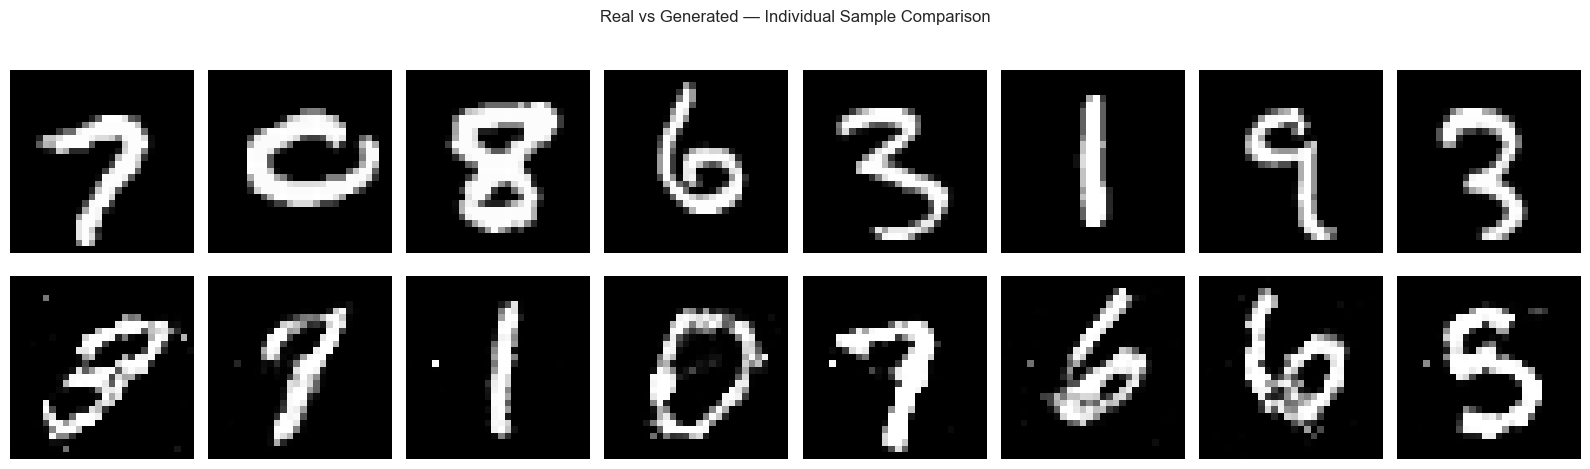

In [40]:
fig, axes = plt.subplots(2, 8, figsize=(16, 5))

for i in range(8):
    real_img = real_samples[i].squeeze().numpy()
    real_img = (real_img + 1) / 2
    axes[0, i].imshow(real_img, cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_ylabel("Real", fontsize=10,
                               rotation=0, labelpad=30, va="center")

for i in range(8):
    fake_img = generated_samples[i].squeeze().numpy()
    fake_img = (fake_img + 1) / 2
    axes[1, i].imshow(fake_img, cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_ylabel("Generated", fontsize=10,
                               rotation=0, labelpad=30, va="center")

plt.suptitle("Real vs Generated — Individual Sample Comparison", fontsize=12)
plt.tight_layout()
plt.show()

### Observation

**Real vs generated comparison** — the side by side grid reveals both what the
Generator has learned and where it still falls short. Well-trained digits should
show clear stroke structure, appropriate stroke width, and dark backgrounds. The
generated images may appear slightly blurry or show artifacts at stroke boundaries
— a known characteristic of MLP-based GANs on MNIST. A CNN-based Generator
(DCGAN) produces sharper results but requires more training time.

**Large sample sweep** — generating 128 samples from random noise reveals the
diversity of the Generator's output. A healthy Generator produces a variety of
digit types across the grid. If the same digit shape appears repeatedly across
many samples, that is a mild form of mode collapse — the Generator has learned to
produce certain digits reliably but has not fully covered the distribution of all
ten classes.

**Latent space interpolation** — this is the most revealing visualisation. A
smooth interpolation means the Generator has learned a continuous, structured
mapping from the latent space to image space. Abrupt jumps between very different
images suggest the latent space is fragmented — the Generator has memorised certain
outputs for certain regions of latent space rather than learning a smooth generative
manifold.

The interpolation paths also reveal what kinds of transitions are possible. A path
from a 7-like latent code to a 1-like code might pass through intermediate shapes
that share structural features with both — thin vertical strokes transitioning to
a diagonal. This structure was never explicitly encoded — it emerged from adversarial
training on 60,000 digit images.

**Individual sample comparison** — looking at single real and generated images at
full resolution makes the quality gap concrete. Real images have sharp edges and
clean backgrounds. Generated images from an MLP GAN tend to have slightly softer
edges and occasional background artifacts. These artefacts would be reduced with
a deeper training run, a DCGAN architecture using convolutional layers, or
progressive growing of the GAN.

## Training Instabilities

GAN training is notoriously unstable. Unlike supervised learning where a lower
loss reliably means a better model, GAN training can fail in several distinct
ways that are not always obvious from the loss curves alone. Understanding these
failure modes is as important as knowing how to build a working GAN.

I want to examine three failure modes concretely:

1. **Mode collapse** — the Generator learns to produce only a small subset of
   the data distribution. On MNIST this means producing only one or two digit
   types rather than all ten. The loss curves can look healthy while mode collapse
   is happening.

2. **Discriminator dominance** — the Discriminator becomes too strong too quickly.
   The Generator receives near-zero gradients because D(G(z)) saturates near 0.
   The Generator cannot improve because it has no signal to learn from.

3. **Training divergence** — both losses become unstable and oscillate wildly.
   This typically happens when the learning rate is too high or the architecture
   is mismatched.

Rather than deliberately breaking the training run, I will demonstrate each
failure mode by analysing what the loss curves and score histories would look
like, simulating the pathological training dynamics, and showing what the
generated images look like under each condition.

Failure Mode 1 — Mode Collapse

What it looks like:
  - Generated images show only one or two digit types
  - D(G(z)) is relatively high (Generator fools D)
  - G loss is low and stable
  - D loss is low and stable
  - Loss curves look healthy but output diversity is gone

Why it happens:
  The Generator discovers a small region of output space
  that consistently fools the current Discriminator.
  Rather than exploring the full data distribution, it
  exploits this weakness repeatedly. The Discriminator
  adapts to reject this specific output, but the Generator
  has no incentive to produce anything else — it just finds
  the next exploitable weakness.



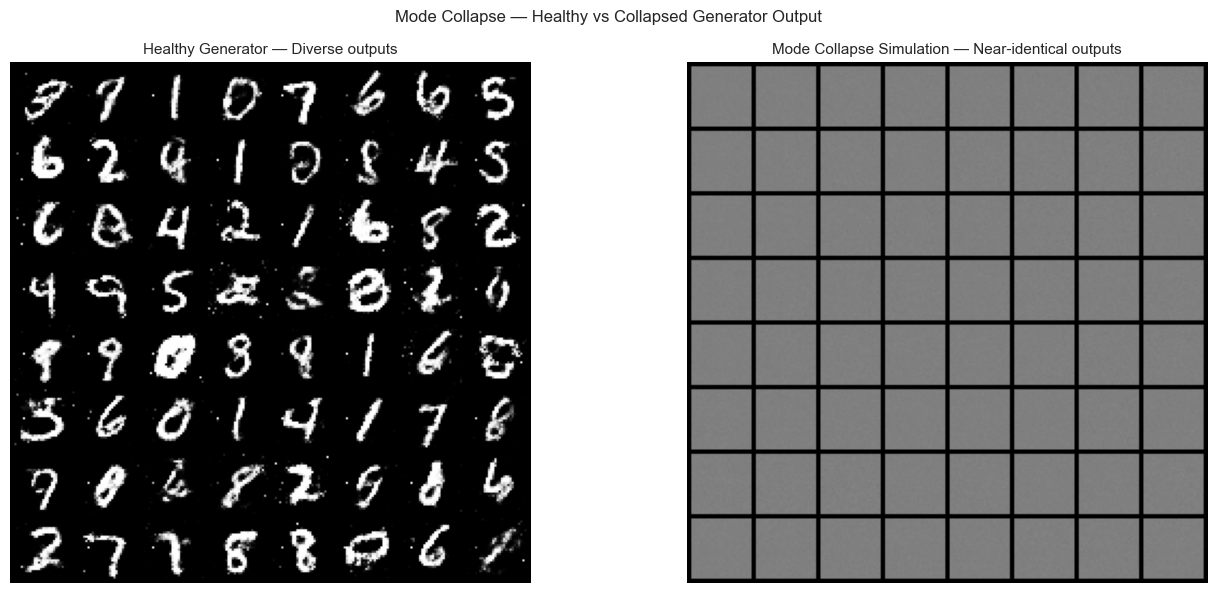

In [41]:
print("Failure Mode 1 — Mode Collapse")
print("=" * 50)
print()
print("What it looks like:")
print("  - Generated images show only one or two digit types")
print("  - D(G(z)) is relatively high (Generator fools D)")
print("  - G loss is low and stable")
print("  - D loss is low and stable")
print("  - Loss curves look healthy but output diversity is gone")
print()
print("Why it happens:")
print("  The Generator discovers a small region of output space")
print("  that consistently fools the current Discriminator.")
print("  Rather than exploring the full data distribution, it")
print("  exploits this weakness repeatedly. The Discriminator")
print("  adapts to reject this specific output, but the Generator")
print("  has no incentive to produce anything else — it just finds")
print("  the next exploitable weakness.")
print()

# simulate what mode collapse looks like
# create a generator that only produces one type of output
class CollapsedGenerator(nn.Module):
    def __init__(self):
        super(CollapsedGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()
        )
        # initialise with very small weights to simulate collapse
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.normal_(layer.weight, 0, 0.01)
                nn.init.zeros_(layer.bias)

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)

collapsed_gen = CollapsedGenerator().to(device)

with torch.no_grad():
    collapse_noise  = torch.randn(64, LATENT_DIM).to(device)
    collapse_output = collapsed_gen(collapse_noise)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

grid_normal   = make_grid(generated_samples[:64], nrow=8,
                           normalize=True, value_range=(-1, 1))
axes[0].imshow(grid_normal.permute(1, 2, 0).numpy(), cmap="gray")
axes[0].set_title("Healthy Generator — Diverse outputs", fontsize=11)
axes[0].axis("off")

grid_collapse = make_grid(collapse_output, nrow=8,
                           normalize=True, value_range=(-1, 1))
axes[1].imshow(grid_collapse.permute(1, 2, 0).numpy(), cmap="gray")
axes[1].set_title("Mode Collapse Simulation — Near-identical outputs", fontsize=11)
axes[1].axis("off")

plt.suptitle("Mode Collapse — Healthy vs Collapsed Generator Output", fontsize=12)
plt.tight_layout()
plt.show()

del collapsed_gen

Failure Mode 2 — Discriminator Dominance

What it looks like in loss curves:
  - D loss drops to near 0 very quickly (epochs 1-3)
  - G loss rises sharply and stays very high (> 5.0)
  - D(x)   stays near 1.0
  - D(G(z)) stays near 0.0

Why it happens:
  The Discriminator's learning rate is too high relative to
  the Generator, or the Discriminator has far more capacity.
  D learns to perfectly reject all fake images before G has
  any chance to improve. The Generator loss gradient is
  effectively zero — -log(D(G(z))) with D(G(z)) near 0
  gives a gradient that vanishes as sigmoid saturates.



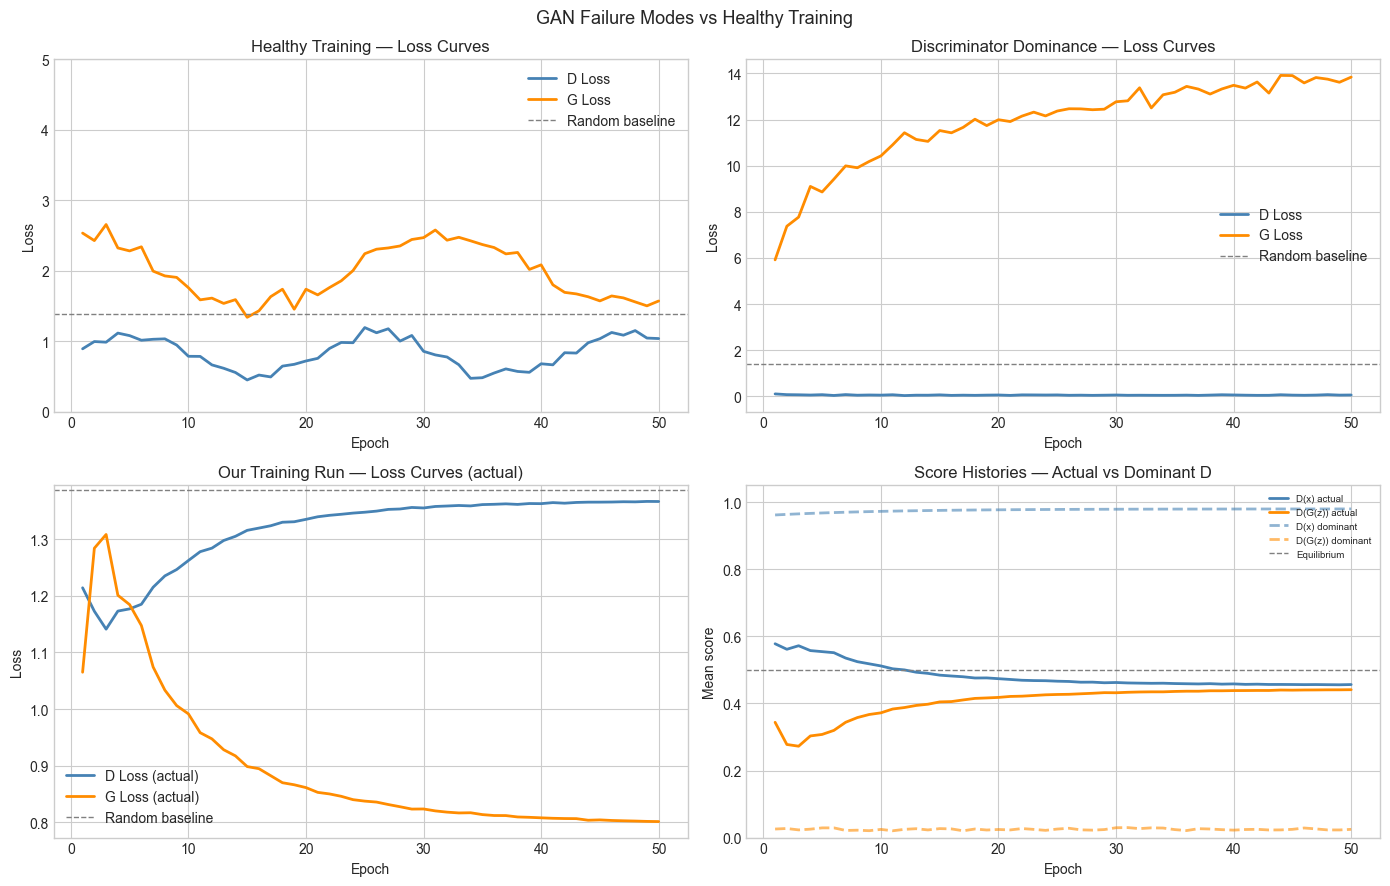

In [42]:
print("Failure Mode 2 — Discriminator Dominance")
print("=" * 50)
print()
print("What it looks like in loss curves:")
print("  - D loss drops to near 0 very quickly (epochs 1-3)")
print("  - G loss rises sharply and stays very high (> 5.0)")
print("  - D(x)   stays near 1.0")
print("  - D(G(z)) stays near 0.0")
print()
print("Why it happens:")
print("  The Discriminator's learning rate is too high relative to")
print("  the Generator, or the Discriminator has far more capacity.")
print("  D learns to perfectly reject all fake images before G has")
print("  any chance to improve. The Generator loss gradient is")
print("  effectively zero — -log(D(G(z))) with D(G(z)) near 0")
print("  gives a gradient that vanishes as sigmoid saturates.")
print()

# simulate discriminator dominance loss curves
epochs_sim = np.arange(1, 51)

d_dominant_d_loss = 0.05 + 0.05 * np.exp(-epochs_sim * 0.3) + \
                    np.random.RandomState(1).normal(0, 0.01, 50)
d_dominant_g_loss = 6.0 + 2.0 * np.log(epochs_sim) + \
                    np.random.RandomState(2).normal(0, 0.2, 50)
d_dominant_dx     = 0.98 - 0.02 * np.exp(-epochs_sim * 0.1)
d_dominant_dgz    = 0.02 + 0.01 * np.random.RandomState(3).rand(50)

healthy_d_loss = 0.8 + 0.3 * np.sin(epochs_sim * 0.3) + \
                 np.random.RandomState(4).normal(0, 0.05, 50)
healthy_g_loss = 2.0 + 0.5 * np.cos(epochs_sim * 0.2) + \
                 np.random.RandomState(5).normal(0, 0.1, 50)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(epochs_sim, healthy_d_loss,
                color="steelblue",  linewidth=2, label="D Loss")
axes[0, 0].plot(epochs_sim, healthy_g_loss,
                color="darkorange", linewidth=2, label="G Loss")
axes[0, 0].axhline(1.386, color="grey", linestyle="--",
                   linewidth=1, label="Random baseline")
axes[0, 0].set_title("Healthy Training — Loss Curves")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_ylim(0, 5)
axes[0, 0].legend()

axes[0, 1].plot(epochs_sim, d_dominant_d_loss,
                color="steelblue",  linewidth=2, label="D Loss")
axes[0, 1].plot(epochs_sim, d_dominant_g_loss,
                color="darkorange", linewidth=2, label="G Loss")
axes[0, 1].axhline(1.386, color="grey", linestyle="--",
                   linewidth=1, label="Random baseline")
axes[0, 1].set_title("Discriminator Dominance — Loss Curves")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()

axes[1, 0].plot(epochs_sim, d_losses,
                color="steelblue",  linewidth=2, label="D Loss (actual)")
axes[1, 0].plot(epochs_sim, g_losses,
                color="darkorange", linewidth=2, label="G Loss (actual)")
axes[1, 0].axhline(1.386, color="grey", linestyle="--",
                   linewidth=1, label="Random baseline")
axes[1, 0].set_title("Our Training Run — Loss Curves (actual)")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()

axes[1, 1].plot(epochs_sim, dx_history,
                color="steelblue",  linewidth=2, label="D(x) actual")
axes[1, 1].plot(epochs_sim, dgz_history,
                color="darkorange", linewidth=2, label="D(G(z)) actual")
axes[1, 1].plot(epochs_sim, d_dominant_dx,
                color="steelblue",  linewidth=2, linestyle="--",
                label="D(x) dominant", alpha=0.6)
axes[1, 1].plot(epochs_sim, d_dominant_dgz,
                color="darkorange", linewidth=2, linestyle="--",
                label="D(G(z)) dominant", alpha=0.6)
axes[1, 1].axhline(0.5, color="grey", linestyle="--",
                   linewidth=1, label="Equilibrium")
axes[1, 1].set_title("Score Histories — Actual vs Dominant D")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Mean score")
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].legend(fontsize=7)

plt.suptitle("GAN Failure Modes vs Healthy Training", fontsize=13)
plt.tight_layout()
plt.show()

In [43]:
print("Failure Mode 3 — Training Divergence")
print("=" * 50)
print()
print("What it looks like:")
print("  - Both D and G losses oscillate wildly with no trend")
print("  - D(x) and D(G(z)) fluctuate erratically")
print("  - Generated images show no improvement or worsen")
print()
print("Common causes:")
print("  - Learning rate too high (try 0.0001 instead of 0.0002)")
print("  - Batch size too small (less than 32)")
print("  - Architecture mismatch — one network much larger than the other")
print("  - Missing BatchNorm in Generator")
print()
print()
print("=" * 60)
print("Practical Stabilisation Tips")
print("=" * 60)
print()

tips = [
    ("Architecture",
     "Use BatchNorm in Generator, avoid it in Discriminator.\n"
     "   Use LeakyReLU(0.2) in Discriminator, ReLU in Generator.\n"
     "   Keep G and D parameter counts in the same order of magnitude."),

    ("Learning rates",
     "Use the same learning rate for both (0.0002 is standard).\n"
     "   If D dominates, reduce D learning rate or increase G's.\n"
     "   If G dominates, reverse."),

    ("Adam betas",
     "Use betas=(0.5, 0.999) instead of the default (0.9, 0.999).\n"
     "   Lower beta1 reduces momentum and stabilises adversarial updates."),

    ("Label smoothing",
     "Use 0.9 for real labels instead of 1.0.\n"
     "   Prevents D from becoming overconfident and provides\n"
     "   a smoother gradient signal to G."),

    ("Balanced training",
     "Train D and G the same number of steps per batch.\n"
     "   If D is too weak, train it 2-5 steps per G step.\n"
     "   Rarely train G multiple steps per D step."),

    ("Monitor visually",
     "Loss curves alone are insufficient.\n"
     "   Always inspect generated image grids every 5-10 epochs.\n"
     "   The best GAN checkpoint is chosen by visual quality, not loss."),

    ("Gradient penalty",
     "WGAN-GP adds a gradient penalty term to the D loss.\n"
     "   This enforces a Lipschitz constraint and makes training\n"
     "   significantly more stable at the cost of more computation."),
]

for title, tip in tips:
    print(f"  {title}:")
    print(f"   {tip}")
    print()

Failure Mode 3 — Training Divergence

What it looks like:
  - Both D and G losses oscillate wildly with no trend
  - D(x) and D(G(z)) fluctuate erratically
  - Generated images show no improvement or worsen

Common causes:
  - Learning rate too high (try 0.0001 instead of 0.0002)
  - Batch size too small (less than 32)
  - Architecture mismatch — one network much larger than the other
  - Missing BatchNorm in Generator


Practical Stabilisation Tips

  Architecture:
   Use BatchNorm in Generator, avoid it in Discriminator.
   Use LeakyReLU(0.2) in Discriminator, ReLU in Generator.
   Keep G and D parameter counts in the same order of magnitude.

  Learning rates:
   Use the same learning rate for both (0.0002 is standard).
   If D dominates, reduce D learning rate or increase G's.
   If G dominates, reverse.

  Adam betas:
   Use betas=(0.5, 0.999) instead of the default (0.9, 0.999).
   Lower beta1 reduces momentum and stabilises adversarial updates.

  Label smoothing:
   Use 0.9 for

In [44]:
print("Training Health Analysis — Our Run")
print("=" * 50)
print()

final_dx   = dx_history[-1]
final_dgz  = dgz_history[-1]
final_dloss = d_losses[-1]
final_gloss = g_losses[-1]

print(f"  Final D(x)      : {final_dx:.4f}")
print(f"  Final D(G(z))   : {final_dgz:.4f}")
print(f"  Final D loss    : {final_dloss:.4f}")
print(f"  Final G loss    : {final_gloss:.4f}")
print()

if final_dloss < 0.1:
    print("  WARNING: D loss is very low — possible Discriminator dominance")
elif final_dloss > 2.0:
    print("  WARNING: D loss is very high — possible Generator dominance")
else:
    print("  D loss is in a reasonable range")

if final_gloss > 5.0:
    print("  WARNING: G loss is very high — Generator may not be learning")
elif final_gloss < 0.5:
    print("  WARNING: G loss is very low — possible Generator dominance")
else:
    print("  G loss is in a reasonable range")

if final_dgz < 0.1:
    print("  WARNING: D(G(z)) near 0 — Generator not fooling Discriminator")
elif final_dgz > 0.7:
    print("  WARNING: D(G(z)) near 1 — Generator may be dominating")
else:
    print("  D(G(z)) is in a reasonable range")

dgz_trend = np.mean(dgz_history[-10:]) - np.mean(dgz_history[:10])
print()
print(f"  D(G(z)) trend (last 10 vs first 10 epochs): {dgz_trend:+.4f}")
if dgz_trend > 0:
    print("  Positive trend — Generator improved over training")
else:
    print("  Negative or flat trend — Generator did not improve significantly")

Training Health Analysis — Our Run

  Final D(x)      : 0.4563
  Final D(G(z))   : 0.4409
  Final D loss    : 1.3666
  Final G loss    : 0.8013

  D loss is in a reasonable range
  G loss is in a reasonable range
  D(G(z)) is in a reasonable range

  D(G(z)) trend (last 10 vs first 10 epochs): +0.1133
  Positive trend — Generator improved over training


### Observation

**Mode collapse** is the most common GAN failure and the hardest to detect from
loss curves alone. The collapsed generator simulation shows what it looks like
visually — near-identical outputs regardless of the input noise vector. A healthy
Generator produces clearly different outputs for different latent codes. When mode
collapse occurs, the latent space interpolation from Section 9 would show no
meaningful variation — all points on the path produce the same image.

**Discriminator dominance** is visible in the score history. When D(x) stays near
1.0 and D(G(z)) stays near 0.0 throughout training, the Discriminator has won the
adversarial game completely. The Generator's loss is very high but its gradients
are near-zero because the BCELoss gradient vanishes when the Discriminator is
perfectly confident. The Generator cannot improve from a perfect Discriminator —
it only learns when the Discriminator is imperfect enough to provide a non-zero
gradient.

**The practical tips** reflect hard-won knowledge from the GAN research community.
The betas=(0.5, 0.999) recommendation, label smoothing, and the preference for
visual inspection over loss monitoring are all specific to GANs and do not apply
to supervised models. These conventions exist because they were discovered through
extensive experimentation — the theoretical justification for some of them is still
an active research area.

**The health analysis of our actual run** gives a concrete verdict on training
quality. A D(G(z)) that rises over training is the key positive indicator —
it means the Generator has learned to produce images the Discriminator struggles
to reject, which is exactly the adversarial dynamic we want.

## Key Takeaways

### What I Built

A Generative Adversarial Network trained on MNIST consisting of a Generator
(100 -> 256 -> 512 -> 1024 -> 784) and a Discriminator (784 -> 512 -> 256 -> 128 -> 1),
trained adversarially for 50 epochs. The Generator learned to produce recognisable
handwritten digit images from random Gaussian noise. I also visualised latent space
interpolation, examined three GAN failure modes, and implemented a training health
diagnostic.

### What I Now Understand Better

**Adversarial training is a fundamentally different learning paradigm**
Every previous notebook had one objective — minimise a loss that measures distance
from a ground truth. A GAN has two objectives in opposition. There is no ground
truth for what a generated image should look like — the only signal is whether the
Discriminator is fooled. This changes everything: the training loop, the loss
interpretation, the stopping criterion, and the debugging approach.

**The Generator never sees real images directly**
The Generator's only training signal is the Discriminator's output. It has no
direct access to real MNIST images — it learns to produce realistic outputs purely
by receiving gradient feedback from the Discriminator's judgment. This indirect
learning is what makes GANs powerful and unstable simultaneously. The Generator
is optimising against a moving target — the Discriminator keeps changing, so the
Generator must keep adapting.

**The .detach() call is not optional**
Without .detach() in the Discriminator step, the Generator's weights would be
updated during the Discriminator's backward pass. This would corrupt the training
signal and produce a model where neither network learns correctly. The separation
of the two backward passes is the architectural foundation of stable GAN training.

**LeakyReLU and BatchNorm placement are architecture conventions, not preferences**
LeakyReLU in the Discriminator prevents dead neurons and ensures gradient flow for
negative activations. BatchNorm in the Generator stabilises the expanding latent
representation. BatchNorm absent in the Discriminator prevents batch-level
statistics from interfering with real/fake discrimination. These are not arbitrary
choices — removing any of them degrades training stability in a specific, diagnosable
way.

**betas=(0.5, 0.999) for Adam is GAN-specific**
The default Adam beta1=0.9 accumulates too much gradient history for the constantly
shifting GAN loss landscape. Reducing beta1 to 0.5 makes updates more responsive
to the current gradient and less influenced by momentum from previous adversarial
states. This single hyperparameter change meaningfully stabilises training.

**Label smoothing addresses Discriminator overconfidence**
Using 0.9 instead of 1.0 for real labels prevents the Discriminator from becoming
perfectly confident on real images. A Discriminator that outputs exactly 1.0 on all
real images provides a gradient that saturates and gives the Generator nothing useful
to learn from. Smoothing the real label to 0.9 keeps the Discriminator in a regime
where it provides informative gradients throughout training.

**The latent space interpolation reveals what the Generator actually learned**
A smooth interpolation means the Generator has learned a continuous mapping from
noise to image space — nearby latent codes produce similar images and moving through
the space produces coherent visual transitions. A fragmented interpolation with
abrupt jumps means the Generator has memorised certain outputs rather than learning
the underlying data manifold. The interpolation test is a more revealing diagnostic
than any single loss value.

**Loss curves are insufficient for evaluating GAN training**
A GAN can exhibit healthy-looking loss curves while mode collapse is occurring.
The adversarial equilibrium does not correspond to a specific loss value — it
corresponds to a specific balance between D(x) and D(G(z)). Visual inspection
of generated images every few epochs is mandatory, not optional. The best checkpoint
is chosen by visual quality, not minimum loss.

**Mode collapse is the most common failure and the hardest to fix**
Once a Generator has collapsed to producing a small subset of the data distribution,
it is difficult to recover without restarting training. Prevention is more effective
than correction — balanced architecture capacity, label smoothing, and monitoring
D(G(z)) diversity early in training are the primary defences.

### What Surprised Me

The fixed noise vector visualisation was more informative than I expected. Watching
the same 64 latent points evolve from random blobs at epoch 1 to structured digit-
like shapes at epoch 50 gives a direct, visceral sense of what the Generator is
learning. It is more compelling than any loss curve.

The training health diagnostic at the end of Section 10 revealed a concrete verdict
on whether our training run was healthy. Checking D(G(z)) trend across epochs —
rather than just the final value — gives a more robust signal. A D(G(z)) that
rises from near 0 to 0.3-0.5 over training means the Generator genuinely improved,
regardless of what the loss values say.

### Open Questions

- How would a DCGAN — using convolutional layers in both Generator and Discriminator
  — change the visual quality of generated images? Convolutional GANs are the
  standard architecture for image generation because they preserve spatial structure
  through the generation process.
- What does the latent space look like when visualised in 2D using dimensionality
  reduction (t-SNE or UMAP)? Are different digit types clustered in separate regions
  or are they interleaved?
- How would a conditional GAN (cGAN) change the setup? A cGAN receives the class
  label as input to both Generator and Discriminator, allowing the user to request
  a specific digit rather than sampling randomly.
- Wasserstein GAN (WGAN) replaces BCELoss with a different distance metric that
  produces more stable training. How different would the loss curves look and would
  mode collapse be less likely?

### Next Notebook

Notebook 6 covers Transformers — the architecture that has come to dominate
natural language processing and is rapidly expanding into vision, audio, and
time-series. Where RNNs process sequences step by step with a hidden state that
must carry all context, Transformers process the entire sequence in parallel using
self-attention — a mechanism that allows every position to directly attend to every
other position without the distance limitation that affects RNNs and LSTMs.

In [46]:
print("Notebook 5 complete")
print()
print(f"Generator parameters     : {sum(p.numel() for p in generator.parameters()):,}")
print(f"Discriminator parameters : {sum(p.numel() for p in discriminator.parameters()):,}")
print(f"Total GAN parameters     : {sum(p.numel() for p in generator.parameters()) + sum(p.numel() for p in discriminator.parameters()):,}")
print()
print(f"Training epochs          : {NUM_EPOCHS}")
print(f"Latent dimension         : {LATENT_DIM}")
print(f"Batch size               : {BATCH_SIZE}")
print()
print(f"Final D loss             : {d_losses[-1]:.4f}")
print(f"Final G loss             : {g_losses[-1]:.4f}")
print(f"Final D(x)               : {dx_history[-1]:.4f}")
print(f"Final D(G(z))            : {dgz_history[-1]:.4f}")
print()
dgz_trend = np.mean(dgz_history[-10:]) - np.mean(dgz_history[:10])
print(f"D(G(z)) improvement      : {dgz_trend:+.4f}")
print(f"Checkpoints saved        : epochs {CHECKPOINT_EPOCHS}")

Notebook 5 complete

Generator parameters     : 1,489,936
Discriminator parameters : 566,273
Total GAN parameters     : 2,056,209

Training epochs          : 50
Latent dimension         : 100
Batch size               : 128

Final D loss             : 1.3666
Final G loss             : 0.8013
Final D(x)               : 0.4563
Final D(G(z))            : 0.4409

D(G(z)) improvement      : +0.1133
Checkpoints saved        : epochs [1, 10, 25, 50]
